# Exploration des données foudre — Meteorage
Analyse du fichier `segment_alerts_all_airports_train.csv`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 1. Import des données

In [2]:
FILE_PATH = "segment_alerts_all_airports_train.csv"

df = pd.read_csv(FILE_PATH)
print("Fichier chargé avec succès")

Fichier chargé avec succès


## 2. Aperçu général

In [3]:
print(f"Nombre de lignes    : {len(df):,}")
print(f"Nombre de colonnes  : {df.shape[1]}")
print(f"\nColonnes : {list(df.columns)}")

Nombre de lignes    : 507,071
Nombre de colonnes  : 13

Colonnes : ['lightning_id', 'lightning_airport_id', 'date', 'lon', 'lat', 'amplitude', 'maxis', 'icloud', 'dist', 'azimuth', 'airport', 'airport_alert_id', 'is_last_lightning_cloud_ground']


In [4]:
# type des colonnes

df.dtypes

lightning_id                        int64
lightning_airport_id                int64
date                               object
lon                               float64
lat                               float64
amplitude                         float64
maxis                             float64
icloud                               bool
dist                              float64
azimuth                           float64
airport                            object
airport_alert_id                  float64
is_last_lightning_cloud_ground     object
dtype: object

In [5]:
# conversion de "date" en type "datetime"
df['date'] = pd.to_datetime(df['date'], utc=True)

In [6]:
# les 5 premières valeurs

df.head()

,lightning_id,lightning_airport_id,date,lon,lat,amplitude,maxis,icloud,dist,azimuth,airport,airport_alert_id,is_last_lightning_cloud_ground
0,1,1,2016-01-02 14:53:36+00:00,9.0559,42.0826,-9.90,0.3,False,27.360653,57.852343,Ajaccio,NaN,NaN
1,2,2,2016-01-02 14:53:36+00:00,9.0236,42.0953,-3.33,0.2,True,26.383167,52.117828,Ajaccio,NaN,NaN
2,3,3,2016-01-02 21:22:53+00:00,8.8585,42.0456,-18.68,0.4,True,14.313391,24.500543,Ajaccio,NaN,NaN
3,4,4,2016-01-02 21:22:53+00:00,8.8517,42.0517,-7.51,0.2,False,14.794117,20.854458,Ajaccio,1.0,False
4,5,5,2016-01-02 21:24:46+00:00,8.8728,42.0494,-6.01,0.2,False,15.124224,29.058471,Ajaccio,1.0,False


## 3. Valeurs manquantes

In [7]:
missing = pd.DataFrame({
    'nb_manquants': df.isnull().sum(),
    'pct_manquants (%)': (df.isnull().sum() / len(df) * 100).round(2)
})

missing = missing.sort_values('pct_manquants (%)', ascending=False)
print(missing.to_string())

                                nb_manquants  pct_manquants (%)
airport_alert_id                      450472              88.84
is_last_lightning_cloud_ground        450472              88.84
date                                       0               0.00
lightning_airport_id                       0               0.00
lightning_id                               0               0.00
lat                                        0               0.00
lon                                        0               0.00
amplitude                                  0               0.00
maxis                                      0               0.00
dist                                       0               0.00
icloud                                     0               0.00
airport                                    0               0.00
azimuth                                    0               0.00


## 4. Statistiques descriptives

In [8]:
df.describe(include='all')

,lightning_id,lightning_airport_id,date,lon,lat,amplitude,maxis,icloud,dist,azimuth,airport,airport_alert_id,is_last_lightning_cloud_ground
count,507071.000000,507071.000000,507071,507071.000000,507071.000000,507071.000000,507071.000000,507071,507071.000000,507071.000000,507071,56599.000000,56599
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,5,NaN,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,NaN,NaN,Pise,NaN,False
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,378079,NaN,NaN,156718,NaN,53972
mean,319152.873651,59451.210188,2019-03-27 03:35:05.546737920+00:00,6.385887,43.345451,-2.254868,1.025518,NaN,20.243757,168.806028,NaN,316.932720,NaN
min,1.000000,1.000000,2016-01-02 01:10:41+00:00,-2.006800,41.654300,-429.500000,0.016000,NaN,0.037212,0.000000,NaN,1.000000,NaN
25%,148099.500000,25354.000000,2017-06-28 16:02:00+00:00,-1.295800,42.471800,-5.610000,0.107000,NaN,15.412370,85.240722,NaN,170.000000,NaN
50%,317158.000000,54199.000000,2018-08-22 13:07:13+00:00,9.339100,43.445100,-1.560000,0.245000,NaN,21.442300,156.717299,NaN,282.000000,NaN
75%,501958.500000,90354.000000,2020-09-20 05:30:42+00:00,10.220500,43.666200,4.620000,1.538000,NaN,26.112228,251.482192,NaN,446.000000,NaN
max,628726.000000,156718.000000,2022-12-21 11:20:11+00:00,10.771700,47.422600,497.000000,6.900000,NaN,29.999996,359.978549,NaN,769.000000,NaN


In [9]:
# nombre d'éclairs en terme de distance

bins = [0, 20, 30, float('inf')]
labels = ['< 20 km', '20-30 km', '> 30 km']

dist_cat = pd.cut(df['dist'], bins=bins, labels=labels)

result = dist_cat.value_counts().sort_index().to_frame(name='nb_eclairs')
result['pct (%)'] = (result['nb_eclairs'] / len(df) * 100).round(2)

result

,nb_eclairs,pct (%)
dist,,
< 20 km,220498,43.48
20-30 km,286573,56.52
> 30 km,0,0.00


In [10]:
# Pourcentage par type d'éclair
print("=== Type d'éclair ===")
type_result = df['icloud'].value_counts().to_frame(name='nb_eclairs')
type_result.index = ['Intra-nuage (True)', 'Nuage-sol (False)']
type_result['pct (%)'] = (type_result['nb_eclairs'] / len(df) * 100).round(2)
print(type_result)

=== Type d'éclair ===
                    nb_eclairs  pct (%)
Intra-nuage (True)      378079    74.56
Nuage-sol (False)       128992    25.44


In [11]:
# Croisement distance x type
print("\n=== Croisement distance x type ===")
bins = [0, 20, 30, float('inf')]
labels = ['< 20 km', '20-30 km', '> 30 km']

dist_cat = pd.cut(df['dist'], bins=bins, labels=labels)

cross = pd.crosstab(dist_cat, df['icloud'], margins=True)
cross.columns = ['Nuage-sol', 'Intra-nuage', 'Total']
cross['pct_nuage_sol (%)'] = (cross['Nuage-sol'] / cross['Total'] * 100).round(2)
cross['pct_intra_nuage (%)'] = (cross['Intra-nuage'] / cross['Total'] * 100).round(2)

cross


=== Croisement distance x type ===


,Nuage-sol,Intra-nuage,Total,pct_nuage_sol (%),pct_intra_nuage (%)
dist,,,,,
< 20 km,56599,163899,220498,25.67,74.33
20-30 km,72393,214180,286573,25.26,74.74
All,128992,378079,507071,25.44,74.56


In [12]:
# stats sur la durée d'une alerte en minutes

# Filtrer les éclairs avec un alert_airport_id
alerts = df[df['airport_alert_id'].notna()].copy()

# Durée de chaque alerte = max(date) - min(date) par alerte
duree = alerts.groupby(['airport', 'airport_alert_id'])['date'].agg(
    debut='min',
    fin='max'
)

duree['duree_minutes'] = (duree['fin'] - duree['debut']).dt.total_seconds() / 60


print(f"Durée médiane d'une alerte : {duree['duree_minutes'].median():.2f} minutes")
print(f"Durée moyenne              : {duree['duree_minutes'].mean():.2f} minutes")
print(f"Durée min                  : {duree['duree_minutes'].min():.2f} minutes")
print(f"Durée max                  : {duree['duree_minutes'].max():.2f} minutes")

Durée médiane d'une alerte : 8.92 minutes
Durée moyenne              : 29.90 minutes
Durée min                  : 0.00 minutes
Durée max                  : 578.72 minutes


In [13]:
# Nombre d'alertes orageuses

nb_alertes = df.groupby(['airport', 'airport_alert_id']).ngroups
print(f"Nombre d'alertes orageuses : {nb_alertes}")
print(df.groupby("airport")["airport_alert_id"].nunique())

Nombre d'alertes orageuses : 2627
airport
Ajaccio     530
Bastia      532
Biarritz    590
Nantes      206
Pise        769
Name: airport_alert_id, dtype: int64


In [14]:
print(f"Lignes totales       : {len(df)}")
print(f"Colonnes             : {list(df.columns)}")
print(f"\nValeurs 'icloud' :")
print(df["icloud"].value_counts(dropna=False).to_string())
print(f"\nProportion IC (True) : {df['icloud'].astype(str).str.lower().eq('true').mean():.1%}")
 

Lignes totales       : 507071
Colonnes             : ['lightning_id', 'lightning_airport_id', 'date', 'lon', 'lat', 'amplitude', 'maxis', 'icloud', 'dist', 'azimuth', 'airport', 'airport_alert_id', 'is_last_lightning_cloud_ground']

Valeurs 'icloud' :
icloud
True     378079
False    128992

Proportion IC (True) : 74.6%


In [15]:
df_feat = pd.read_parquet("features.parquet")

# Récupérer la date du premier éclair CG de chaque alerte
first_cg = (
    df[df["icloud"] == False]
    .groupby(["airport", "airport_alert_id"])["date"]
    .min()
    .reset_index()
    .rename(columns={"date": "t_start"})
)

df = df_feat.merge(first_cg, on=["airport", "airport_alert_id"], how="left")
df["hour"] = df["t_start"].dt.hour
df["month"] = df["t_start"].dt.month
df["season"] = df["month"].map({
    12: "Hiver", 1: "Hiver", 2: "Hiver",
    3: "Printemps", 4: "Printemps", 5: "Printemps",
    6: "Été", 7: "Été", 8: "Été",
    9: "Automne", 10: "Automne", 11: "Automne"
})

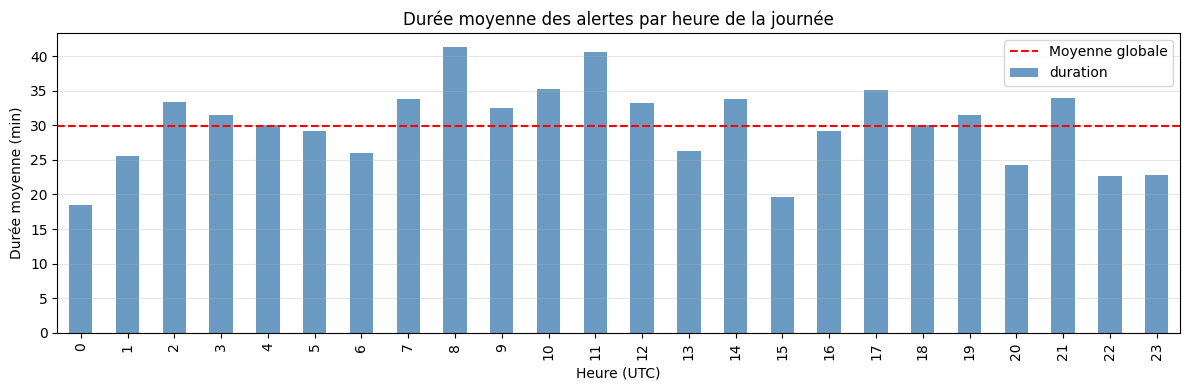

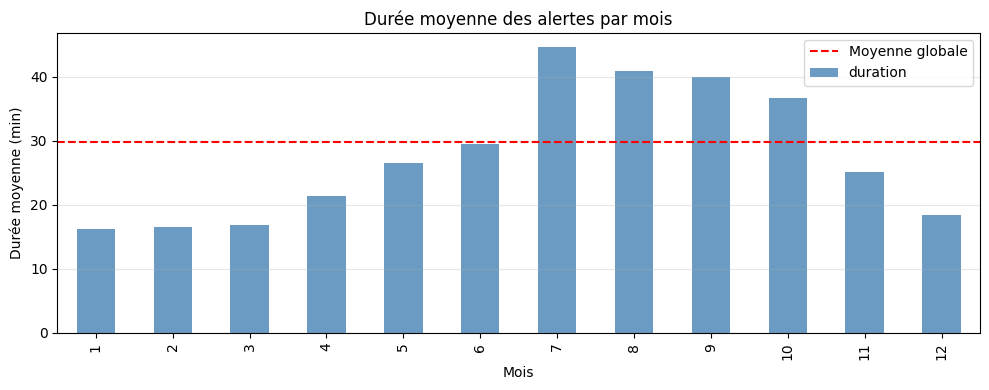

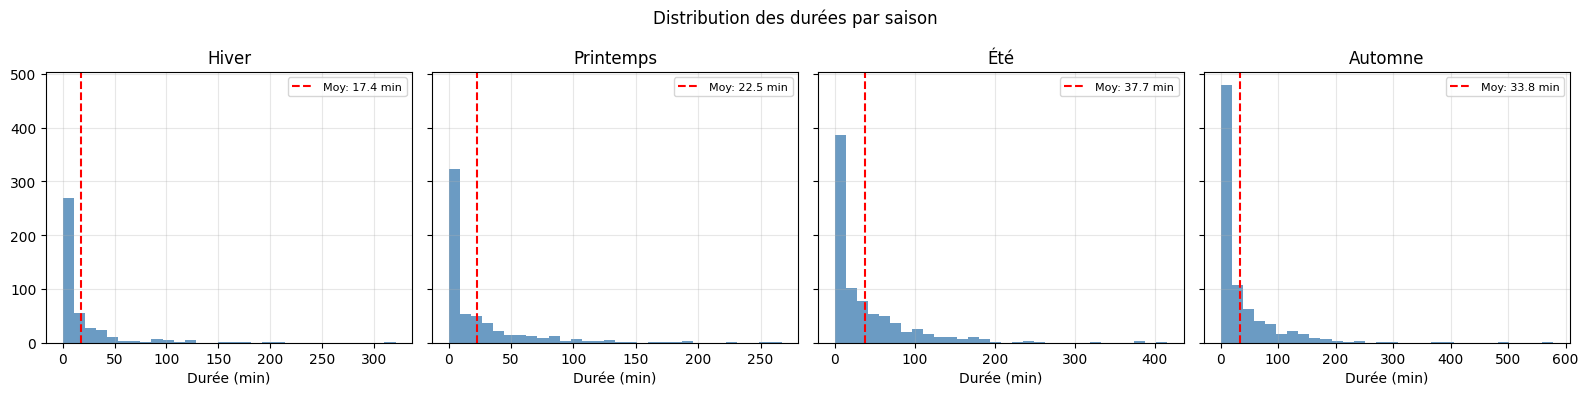

Durée moyenne par saison :
           mean  median  count
season                        
Automne    33.8    10.1    807
Hiver      17.4     2.6    419
Printemps  22.5     5.2    580
Été        37.7    16.8    821

Durée moyenne par heure (top 5 heures les plus longues) :
hour
8     41.3
11    40.6
10    35.2
17    35.0
21    33.9
Name: duration, dtype: float64

Correlation heure/durée : -0.004
Correlation mois/durée  : 0.066


In [16]:

# ── 1. Durée moyenne par heure ───────────────────────────────────────
plt.figure(figsize=(12, 4))
df.groupby("hour")["duration"].mean().plot(kind="bar", color="steelblue", alpha=0.8)
plt.axhline(df["duration"].mean(), color="red", linestyle="--", label="Moyenne globale")
plt.title("Durée moyenne des alertes par heure de la journée")
plt.xlabel("Heure (UTC)")
plt.ylabel("Durée moyenne (min)")
plt.legend()
plt.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

# ── 2. Durée moyenne par mois ────────────────────────────────────────
plt.figure(figsize=(10, 4))
df.groupby("month")["duration"].mean().plot(kind="bar", color="steelblue", alpha=0.8)
plt.axhline(df["duration"].mean(), color="red", linestyle="--", label="Moyenne globale")
plt.title("Durée moyenne des alertes par mois")
plt.xlabel("Mois")
plt.ylabel("Durée moyenne (min)")
plt.legend()
plt.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

# ── 3. Distribution des durées par saison ────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, saison in zip(axes, ["Hiver", "Printemps", "Été", "Automne"]):
    data = df[df["season"] == saison]["duration"]
    ax.hist(data, bins=30, color="steelblue", alpha=0.8)
    ax.axvline(data.mean(), color="red", linestyle="--", label=f"Moy: {data.mean():.1f} min")
    ax.set_title(saison)
    ax.set_xlabel("Durée (min)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
plt.suptitle("Distribution des durées par saison")
plt.tight_layout()
plt.show()

# ── 4. Stats résumées ────────────────────────────────────────────────
print("Durée moyenne par saison :")
print(df.groupby("season")["duration"].agg(["mean", "median", "count"]).round(1))

print("\nDurée moyenne par heure (top 5 heures les plus longues) :")
print(df.groupby("hour")["duration"].mean().sort_values(ascending=False).head(5).round(1))

print("\nCorrelation heure/durée :", df["hour"].corr(df["duration"]).round(3))
print("Correlation mois/durée  :", df["month"].corr(df["duration"]).round(3))

          n_alerts  mean_duration  median_duration  std_duration
airport                                                         
Pise           769          33.10            11.30         54.15
Bastia         532          32.18            10.14         55.98
Ajaccio        530          28.52             8.38         45.30
Nantes         206          27.86             8.77         44.86
Biarritz       590          25.64             7.07         45.16


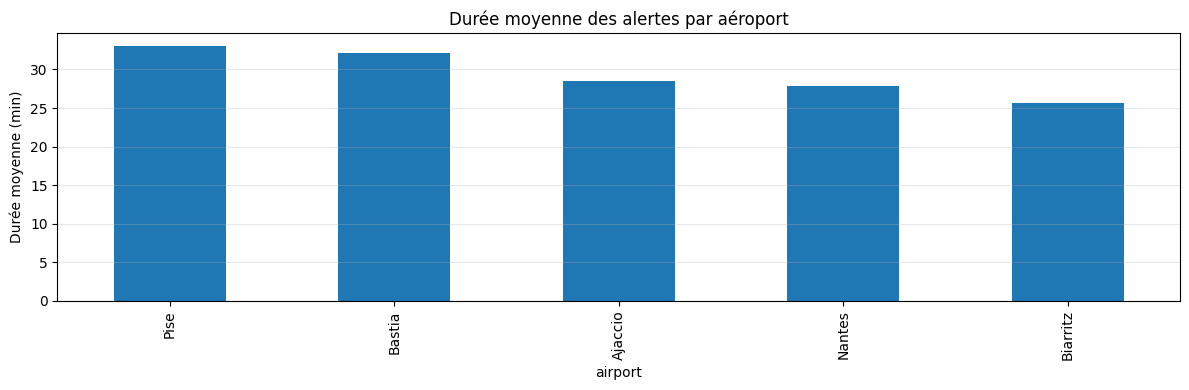

In [17]:
df_alerts = df.copy()
import pandas as pd
import matplotlib.pyplot as plt

# df_alerts : une ligne par alerte
# colonnes attendues : airport, airport_alert_id, duration

airport_stats = (
    df_alerts.groupby("airport")
    .agg(
        n_alerts=("airport_alert_id", "nunique"),
        mean_duration=("duration", "mean"),
        median_duration=("duration", "median"),
        std_duration=("duration", "std"),
    )
    .sort_values("mean_duration", ascending=False)
)

print(airport_stats.round(2))

airport_stats["mean_duration"].plot(kind="bar", figsize=(12, 4))
plt.title("Durée moyenne des alertes par aéroport")
plt.ylabel("Durée moyenne (min)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

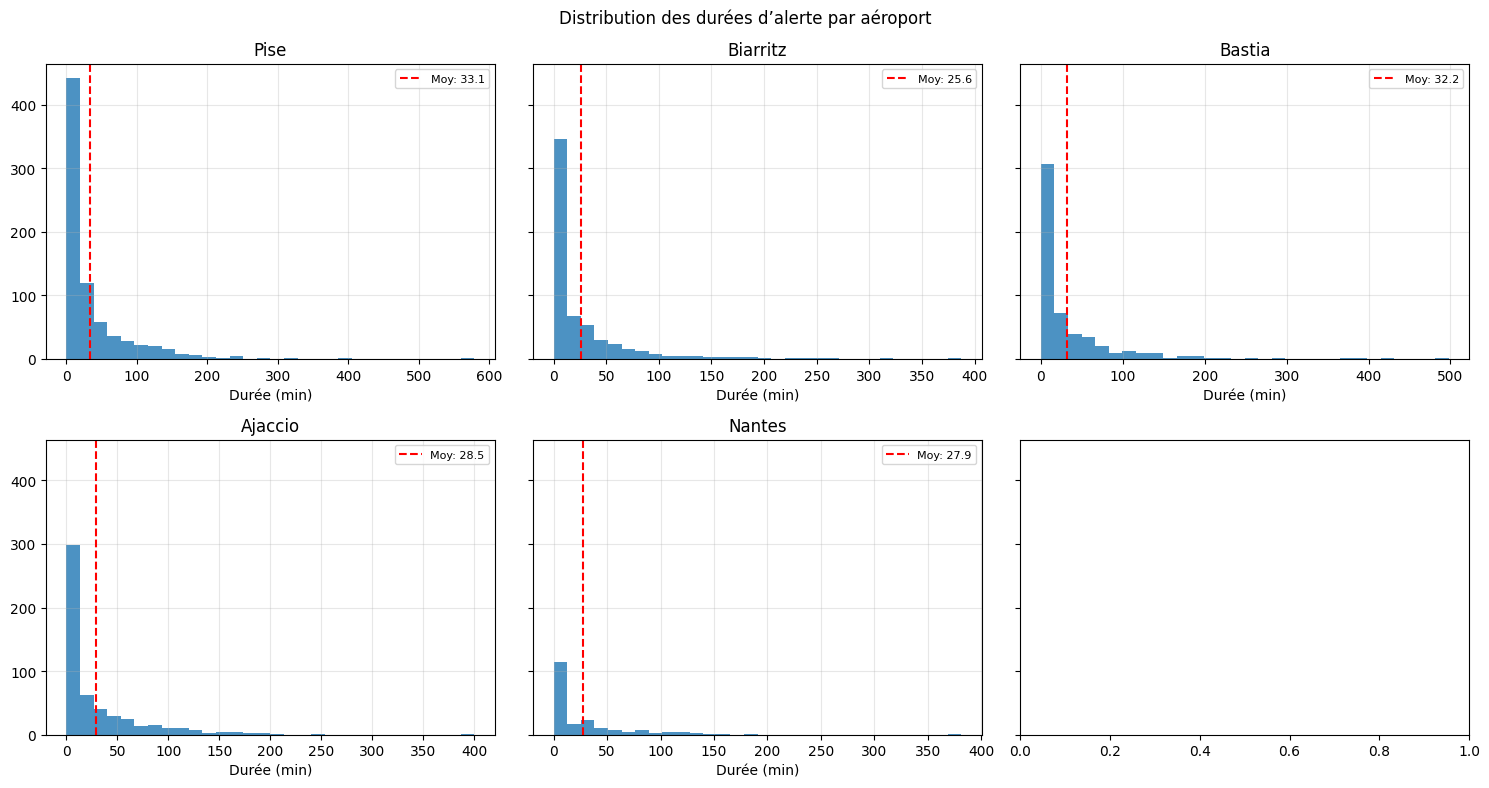

In [18]:
import matplotlib.pyplot as plt

top_airports = df_alerts["airport"].value_counts().head(6).index

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=False, sharey=True)
axes = axes.ravel()

for ax, airport in zip(axes, top_airports):
    data = df_alerts.loc[df_alerts["airport"] == airport, "duration"]
    ax.hist(data, bins=30, alpha=0.8)
    ax.axvline(data.mean(), color="red", linestyle="--", label=f"Moy: {data.mean():.1f}")
    ax.set_title(airport)
    ax.set_xlabel("Durée (min)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("Distribution des durées d’alerte par aéroport")
plt.tight_layout()
plt.show()

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

FILE_PATH = "segment_alerts_all_airports_train.csv"

df = pd.read_csv(FILE_PATH)
print("Fichier chargé avec succès")
print(df.columns.tolist())
df.head()

Fichier chargé avec succès
['lightning_id', 'lightning_airport_id', 'date', 'lon', 'lat', 'amplitude', 'maxis', 'icloud', 'dist', 'azimuth', 'airport', 'airport_alert_id', 'is_last_lightning_cloud_ground']


,lightning_id,lightning_airport_id,date,lon,lat,amplitude,maxis,icloud,dist,azimuth,airport,airport_alert_id,is_last_lightning_cloud_ground
0,1,1,2016-01-02 14:53:36+00:00,9.0559,42.0826,-9.90,0.3,False,27.360653,57.852343,Ajaccio,NaN,NaN
1,2,2,2016-01-02 14:53:36+00:00,9.0236,42.0953,-3.33,0.2,True,26.383167,52.117828,Ajaccio,NaN,NaN
2,3,3,2016-01-02 21:22:53+00:00,8.8585,42.0456,-18.68,0.4,True,14.313391,24.500543,Ajaccio,NaN,NaN
3,4,4,2016-01-02 21:22:53+00:00,8.8517,42.0517,-7.51,0.2,False,14.794117,20.854458,Ajaccio,1.0,False
4,5,5,2016-01-02 21:24:46+00:00,8.8728,42.0494,-6.01,0.2,False,15.124224,29.058471,Ajaccio,1.0,False


In [20]:
# À lancer une seule fois avant les analyses ci-dessous

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- brut événementiel ---
FILE_PATH = "segment_alerts_all_airports_train.csv"
df_raw = pd.read_csv(FILE_PATH)
df_raw["date"] = pd.to_datetime(df_raw["date"], utc=True)
df_raw["type"] = np.where(df_raw["icloud"].fillna(False), "IC", "CG")
df_raw["zone"] = np.where(df_raw["dist"] < 20, "inner", "outer")

# --- niveau alerte ---
df_feat = pd.read_parquet("features.parquet")

first_cg = (
    df_raw[(df_raw["type"] == "CG") & (df_raw["airport_alert_id"].notna())]
    .groupby(["airport", "airport_alert_id"])["date"]
    .min()
    .reset_index()
    .rename(columns={"date": "t_start"})
)

df_alerts = df_feat.merge(first_cg, on=["airport", "airport_alert_id"], how="left")
df_alerts["hour"] = df_alerts["t_start"].dt.hour
df_alerts["month"] = df_alerts["t_start"].dt.month
df_alerts["season"] = df_alerts["month"].map({
    12: "Hiver", 1: "Hiver", 2: "Hiver",
    3: "Printemps", 4: "Printemps", 5: "Printemps",
    6: "Été", 7: "Été", 8: "Été",
    9: "Automne", 10: "Automne", 11: "Automne"
})

print("df_raw :", df_raw.shape)
print("df_alerts :", df_alerts.shape)
print(df_alerts[["airport", "airport_alert_id", "duration", "hour", "month", "season"]].head())


df_raw : (507071, 15)
df_alerts : (2627, 67)
   airport  airport_alert_id  duration  hour  month season
0  Ajaccio               1.0  6.016667    21      1  Hiver
1  Ajaccio               2.0  0.000000     6      1  Hiver
2  Ajaccio               3.0  0.000000     7      1  Hiver
3  Ajaccio               4.0  0.000000    14      2  Hiver
4  Ajaccio               5.0  0.000000    14      2  Hiver


count    1682.00
mean        6.97
std         6.99
min         0.00
25%         2.00
50%         4.18
75%         9.80
max        29.65
Name: gap_before_last_cg_inner_min, dtype: float64


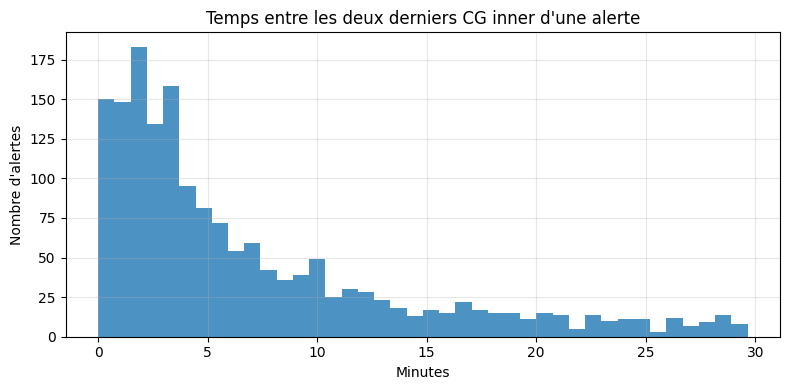

In [21]:
cg_inner = df_raw[
    (df_raw["type"] == "CG") &
    (df_raw["dist"] < 20) &
    (df_raw["airport_alert_id"].notna())
].copy()

last_two = (
    cg_inner.sort_values(["airport", "airport_alert_id", "date"])
    .groupby(["airport", "airport_alert_id"])["date"]
    .apply(lambda s: s.tail(2).tolist())
    .reset_index(name="last_two_dates")
)

def gap_last_two(x):
    if len(x) < 2:
        return np.nan
    return (x[-1] - x[-2]).total_seconds() / 60

last_two["gap_before_last_cg_inner_min"] = last_two["last_two_dates"].apply(gap_last_two)

print(last_two["gap_before_last_cg_inner_min"].describe().round(2))

plt.figure(figsize=(8, 4))
plt.hist(last_two["gap_before_last_cg_inner_min"].dropna(), bins=40, alpha=0.8)
plt.title("Temps entre les deux derniers CG inner d'une alerte")
plt.xlabel("Minutes")
plt.ylabel("Nombre d'alertes")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
# Q1.3 — contexte des 10 min avant le dernier CG inner (version rapide)

last_cg = (
    df_raw[
        (df_raw["type"] == "CG") &
        (df_raw["dist"] < 20) &
        (df_raw["airport_alert_id"].notna())
    ]
    .groupby(["airport", "airport_alert_id"], as_index=False)["date"]
    .max()
    .rename(columns={"date": "last_cg_time"})
)

ctx = (
    df_raw[df_raw["airport_alert_id"].notna()][["airport", "airport_alert_id", "date", "dist", "type"]]
    .merge(last_cg, on=["airport", "airport_alert_id"], how="inner")
)

ctx = ctx[
    (ctx["date"] <= ctx["last_cg_time"]) &
    (ctx["date"] > ctx["last_cg_time"] - pd.Timedelta(minutes=10))
].copy()

ctx["is_outer_20_30"] = (ctx["dist"] >= 20) & (ctx["dist"] < 30)
ctx["is_cg_outer_20_30"] = (ctx["type"] == "CG") & ctx["is_outer_20_30"]

df_lastcg_context = (
    ctx.groupby(["airport", "airport_alert_id", "last_cg_time"], as_index=False)
    .agg(
        n_total_last_10m_before_last_cg=("date", "size"),
        n_outer_last_10m_before_last_cg=("is_outer_20_30", "sum"),
        n_cg_outer_last_10m_before_last_cg=("is_cg_outer_20_30", "sum"),
        dist_min_last_10m_before_last_cg=("dist", "min"),
        dist_mean_last_10m_before_last_cg=("dist", "mean"),
    )
)

print(df_lastcg_context.head())
print(df_lastcg_context.describe(include="all"))

   airport  airport_alert_id              last_cg_time  \
0  Ajaccio               1.0 2016-01-02 21:28:54+00:00   
1  Ajaccio               2.0 2016-01-12 06:37:45+00:00   
2  Ajaccio               3.0 2016-01-12 07:25:37+00:00   
3  Ajaccio               4.0 2016-02-07 14:05:14+00:00   
4  Ajaccio               5.0 2016-02-07 14:35:39+00:00   

   n_total_last_10m_before_last_cg  n_outer_last_10m_before_last_cg  \
0                                5                                0   
1                                1                                0   
2                                1                                0   
3                                1                                0   
4                                1                                0   

   n_cg_outer_last_10m_before_last_cg  dist_min_last_10m_before_last_cg  \
0                                   0                         14.794117   
1                                   0                         12.875968   

In [23]:
alert_summary = (
    df_raw[df_raw["airport_alert_id"].notna()]
    .groupby(["airport", "airport_alert_id"])
    .agg(
        n_events=("date", "size"),
        n_cg_inner=("dist", lambda s: ((df_raw.loc[s.index, "type"] == "CG") & (df_raw.loc[s.index, "dist"] < 20)).sum()),
        min_dist=("dist", "min"),
    )
    .reset_index()
)

alert_summary = alert_summary.merge(
    df_alerts[["airport", "airport_alert_id", "duration"]],
    on=["airport", "airport_alert_id"],
    how="left"
)

print(alert_summary[["duration", "n_events", "n_cg_inner", "min_dist"]].corr().round(3))

            duration  n_events  n_cg_inner  min_dist
duration       1.000     0.654       0.654    -0.567
n_events       0.654     1.000       1.000    -0.327
n_cg_inner     0.654     1.000       1.000    -0.327
min_dist      -0.567    -0.327      -0.327     1.000


In [24]:
CLOSE_RADIUS_KM = 3.0

close_per_alert = (
    df_raw[df_raw["airport_alert_id"].notna()]
    .assign(is_cg_close=lambda x: (x["type"] == "CG") & (x["dist"] < CLOSE_RADIUS_KM))
    .groupby(["airport", "airport_alert_id"])["is_cg_close"]
    .max()
    .reset_index(name="has_close_cg")
)

print("Part globale d'alertes avec au moins un CG < 3 km :")
print(f"{100 * close_per_alert['has_close_cg'].mean():.2f}%")

print("\nPar aéroport :")
print((100 * close_per_alert.groupby('airport')["has_close_cg"].mean()).round(2).sort_values(ascending=False))

Part globale d'alertes avec au moins un CG < 3 km :
13.67%

Par aéroport :
airport
Nantes      17.48
Biarritz    14.07
Ajaccio     13.96
Pise        13.52
Bastia      11.65
Name: has_close_cg, dtype: float64


               mean  median  count
has_close_cg                      
False         19.01    4.57   2268
True          98.72   80.63    359


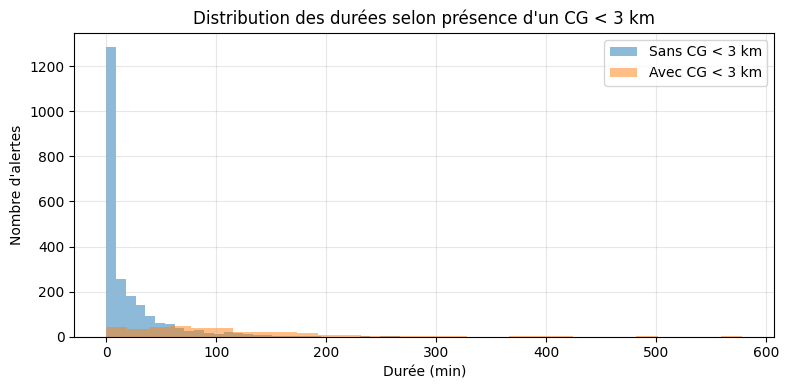

In [25]:
alert_close = df_alerts.merge(
    close_per_alert,
    on=["airport", "airport_alert_id"],
    how="left"
).fillna({"has_close_cg": 0})

print(
    alert_close.groupby("has_close_cg")["duration"]
    .agg(["mean", "median", "count"])
    .round(2)
)

plt.figure(figsize=(8, 4))
for label, val in [("Sans CG < 3 km", 0), ("Avec CG < 3 km", 1)]:
    data = alert_close.loc[alert_close["has_close_cg"] == val, "duration"].dropna()
    plt.hist(data, bins=30, alpha=0.5, label=label)

plt.title("Distribution des durées selon présence d'un CG < 3 km")
plt.xlabel("Durée (min)")
plt.ylabel("Nombre d'alertes")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

count    2627.00
mean       10.89
std         5.95
min         0.04
25%         5.73
50%        11.51
75%        16.28
max        19.99
Name: min_dist, dtype: float64


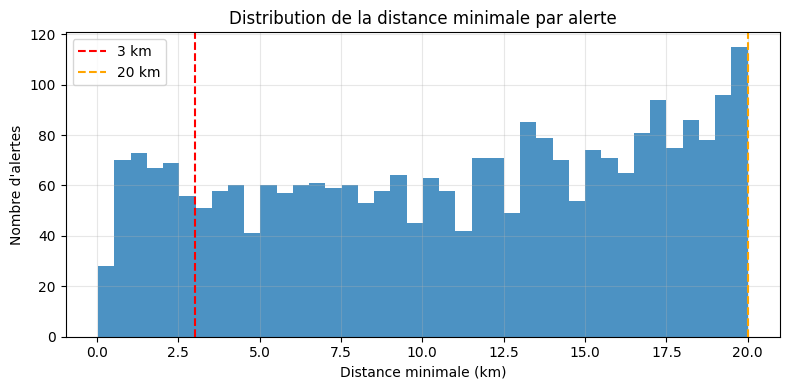

In [26]:
min_dist_per_alert = (
    df_raw[df_raw["airport_alert_id"].notna()]
    .groupby(["airport", "airport_alert_id"])["dist"]
    .min()
    .reset_index(name="min_dist")
)

print(min_dist_per_alert["min_dist"].describe().round(2))

plt.figure(figsize=(8, 4))
plt.hist(min_dist_per_alert["min_dist"], bins=40, alpha=0.8)
plt.axvline(3, color="red", linestyle="--", label="3 km")
plt.axvline(20, color="orange", linestyle="--", label="20 km")
plt.title("Distribution de la distance minimale par alerte")
plt.xlabel("Distance minimale (km)")
plt.ylabel("Nombre d'alertes")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [27]:
cg_inner_counts = (
    df_raw[df_raw["airport_alert_id"].notna()]
    .assign(is_cg_inner=lambda x: (x["type"] == "CG") & (x["dist"] < 20))
    .groupby(["airport", "airport_alert_id"])["is_cg_inner"]
    .sum()
    .reset_index(name="n_cg_inner")
)

close_profile = (
    close_per_alert
    .merge(cg_inner_counts, on=["airport", "airport_alert_id"], how="left")
    .merge(df_alerts[["airport", "airport_alert_id", "duration"]], on=["airport", "airport_alert_id"], how="left")
)

print(close_profile.groupby("has_close_cg")[["n_cg_inner", "duration"]].agg(["mean", "median"]).round(2))

             n_cg_inner        duration       
                   mean median     mean median
has_close_cg                                  
False              7.18    2.0    19.01   4.57
True             112.33   45.0    98.72  80.63


In [28]:
airport_summary = (
    df_alerts.groupby("airport")
    .agg(
        n_alerts=("airport_alert_id", "nunique"),
        mean_duration=("duration", "mean"),
        median_duration=("duration", "median"),
        std_duration=("duration", "std"),
    )
    .reset_index()
)

cg_inner_per_alert = (
    df_raw[df_raw["airport_alert_id"].notna()]
    .assign(is_cg_inner=lambda x: (x["type"] == "CG") & (x["dist"] < 20))
    .groupby(["airport", "airport_alert_id"])["is_cg_inner"]
    .sum()
    .reset_index(name="n_cg_inner")
)

airport_cg = (
    cg_inner_per_alert.groupby("airport")["n_cg_inner"]
    .agg(mean_cg_inner="mean", median_cg_inner="median")
    .reset_index()
)

airport_min_dist = (
    min_dist_per_alert.groupby("airport")["min_dist"]
    .agg(mean_min_dist="mean", median_min_dist="median")
    .reset_index()
)

airport_close = (
    close_per_alert.groupby("airport")["has_close_cg"]
    .mean()
    .reset_index(name="rate_close_cg")
)

airport_full = (
    airport_summary
    .merge(airport_cg, on="airport", how="left")
    .merge(airport_min_dist, on="airport", how="left")
    .merge(airport_close, on="airport", how="left")
)

airport_full["rate_close_cg"] = 100 * airport_full["rate_close_cg"]

print(airport_full.round(2).sort_values("mean_duration", ascending=False))

    airport  n_alerts  mean_duration  median_duration  std_duration  \
4      Pise       769          33.10            11.30         54.15   
1    Bastia       532          32.18            10.14         55.98   
0   Ajaccio       530          28.52             8.38         45.30   
3    Nantes       206          27.86             8.77         44.86   
2  Biarritz       590          25.64             7.07         45.16   

   mean_cg_inner  median_cg_inner  mean_min_dist  median_min_dist  \
4          23.30              3.0          10.69            11.25   
1          25.83              3.0          11.36            12.22   
0          20.09              2.0          11.07            11.74   
3          21.25              2.0          10.42            11.11   
2          16.80              3.0          10.72            10.89   

   rate_close_cg  
4          13.52  
1          11.65  
0          13.96  
3          17.48  
2          14.07  


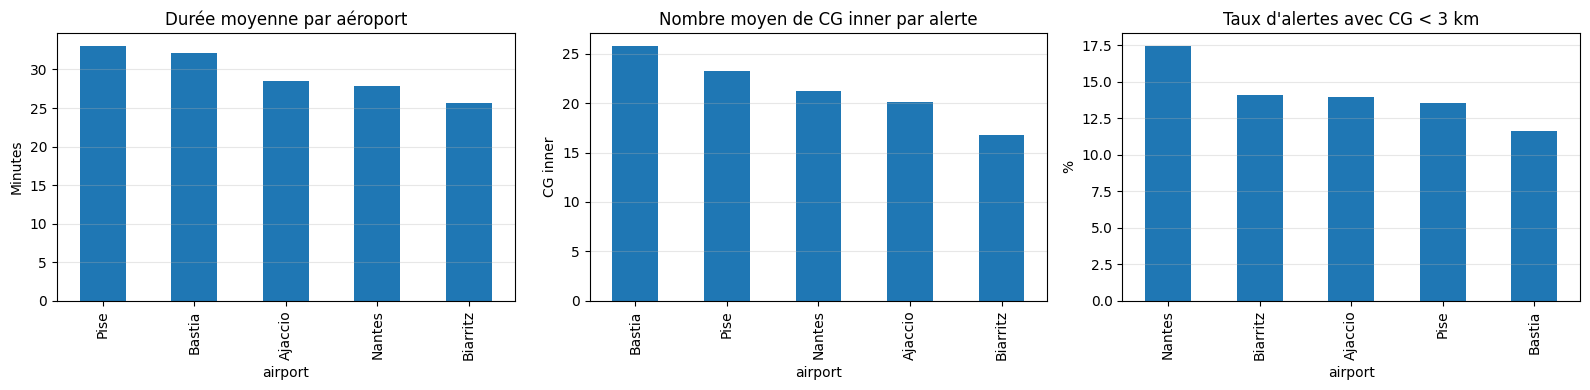

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

airport_full.sort_values("mean_duration", ascending=False).plot(
    x="airport", y="mean_duration", kind="bar", ax=axes[0], legend=False
)
axes[0].set_title("Durée moyenne par aéroport")
axes[0].set_ylabel("Minutes")
axes[0].grid(axis="y", alpha=0.3)

airport_full.sort_values("mean_cg_inner", ascending=False).plot(
    x="airport", y="mean_cg_inner", kind="bar", ax=axes[1], legend=False
)
axes[1].set_title("Nombre moyen de CG inner par alerte")
axes[1].set_ylabel("CG inner")
axes[1].grid(axis="y", alpha=0.3)

airport_full.sort_values("rate_close_cg", ascending=False).plot(
    x="airport", y="rate_close_cg", kind="bar", ax=axes[2], legend=False
)
axes[2].set_title("Taux d'alertes avec CG < 3 km")
axes[2].set_ylabel("%")
axes[2].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [30]:
alert_type_df = (
    df_alerts[["airport", "airport_alert_id", "duration"]]
    .merge(cg_inner_counts, on=["airport", "airport_alert_id"], how="left")
    .merge(min_dist_per_alert, on=["airport", "airport_alert_id"], how="left")
    .merge(close_per_alert, on=["airport", "airport_alert_id"], how="left")
)

# qcut robuste aux ex aequo
alert_type_df["duration_bin"] = pd.qcut(
    alert_type_df["duration"].rank(method="first"),
    q=3,
    labels=["courte", "moyenne", "longue"]
)

alert_type_df["cg_inner_bin"] = pd.qcut(
    alert_type_df["n_cg_inner"].rank(method="first"),
    q=3,
    labels=["faible", "moyen", "fort"]
)

alert_type_df["proximity_bin"] = pd.cut(
    alert_type_df["min_dist"],
    bins=[0, 3, 10, 20, np.inf],
    labels=["<3 km", "3-10 km", "10-20 km", ">20 km"],
    include_lowest=True
)

print(alert_type_df.head())

print("\nTypologie durée x intensité :")
print(pd.crosstab(alert_type_df["duration_bin"], alert_type_df["cg_inner_bin"]))

print("\nTypologie durée x proximité :")
print(pd.crosstab(alert_type_df["duration_bin"], alert_type_df["proximity_bin"]))

   airport  airport_alert_id  duration  n_cg_inner   min_dist  has_close_cg  \
0  Ajaccio               1.0  6.016667           5  14.794117         False   
1  Ajaccio               2.0  0.000000           1  12.875968         False   
2  Ajaccio               3.0  0.000000           1   6.347720         False   
3  Ajaccio               4.0  0.000000           1   3.033382         False   
4  Ajaccio               5.0  0.000000           1  17.927176         False   

  duration_bin cg_inner_bin proximity_bin  
0      moyenne        moyen      10-20 km  
1       courte       faible      10-20 km  
2       courte       faible       3-10 km  
3       courte       faible       3-10 km  
4       courte       faible      10-20 km  

Typologie durée x intensité :
cg_inner_bin  faible  moyen  fort
duration_bin                     
courte           857     19     0
moyenne           19    721   135
longue             0    135   741

Typologie durée x proximité :
proximity_bin  <3 km  3-10 km

In [31]:
type_by_airport = pd.crosstab(
    alert_type_df["airport"],
    alert_type_df["proximity_bin"],
    normalize="index"
) * 100

print(type_by_airport.round(1))

proximity_bin  <3 km  3-10 km  10-20 km
airport                                
Ajaccio         14.0     27.5      58.5
Bastia          11.7     29.1      59.2
Biarritz        14.1     31.7      54.2
Nantes          17.5     27.7      54.9
Pise            13.5     32.0      54.5


In [32]:
alert_local = alert_type_df.merge(
    df_alerts[["airport", "airport_alert_id", "hour", "month"]],
    on=["airport", "airport_alert_id"],
    how="left"
)

for airport, sub in alert_local.groupby("airport"):
    print(f"\n--- {airport} ---")
    print(sub[["duration", "n_cg_inner", "min_dist", "hour", "month"]].corr().round(2))


--- Ajaccio ---
            duration  n_cg_inner  min_dist  hour  month
duration        1.00        0.60     -0.60  0.03   0.03
n_cg_inner      0.60        1.00     -0.40  0.00   0.03
min_dist       -0.60       -0.40      1.00 -0.05   0.02
hour            0.03        0.00     -0.05  1.00  -0.01
month           0.03        0.03      0.02 -0.01   1.00

--- Bastia ---
            duration  n_cg_inner  min_dist  hour  month
duration        1.00        0.66     -0.55 -0.04   0.09
n_cg_inner      0.66        1.00     -0.29 -0.04   0.06
min_dist       -0.55       -0.29      1.00  0.00  -0.09
hour           -0.04       -0.04      0.00  1.00  -0.09
month           0.09        0.06     -0.09 -0.09   1.00

--- Biarritz ---
            duration  n_cg_inner  min_dist  hour  month
duration        1.00        0.65     -0.55 -0.02  -0.03
n_cg_inner      0.65        1.00     -0.36  0.01  -0.04
min_dist       -0.55       -0.36      1.00  0.00  -0.00
hour           -0.02        0.01      0.00  1.00  -0.

In [33]:
# %%
# Setup — à lancer en premier (recharge tout si kernel redémarré)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

FILE_PATH = "segment_alerts_all_airports_train.csv"

df_raw = pd.read_csv(FILE_PATH)
df_raw["date"] = pd.to_datetime(df_raw["date"], utc=True)
df_raw["type"] = np.where(df_raw["icloud"].fillna(False), "IC", "CG")
df_raw["zone"] = np.where(df_raw["dist"] < 20, "inner", "outer")

df_feat = pd.read_parquet("features.parquet")

first_cg = (
    df_raw[(df_raw["type"] == "CG") & (df_raw["airport_alert_id"].notna())]
    .groupby(["airport", "airport_alert_id"])["date"]
    .min()
    .reset_index()
    .rename(columns={"date": "t_start"})
)

df_alerts = df_feat.merge(first_cg, on=["airport", "airport_alert_id"], how="left")

print(f"df_raw   : {df_raw.shape}")
print(f"df_alerts: {df_alerts.shape}")

df_raw   : (507071, 15)
df_alerts: (2627, 66)


In [34]:
# %%
# Chunk 1 corrigé — coordonnées officielles ICAO des 5 aéroports

airport_coords = {
    "Ajaccio":  {"lat": 41.9236, "lon":  8.8029},  # LFKJ
    "Bastia":   {"lat": 42.5527, "lon":  9.4837},  # LFKB
    "Biarritz": {"lat": 43.4684, "lon": -1.5232},  # LFBZ
    "Nantes":   {"lat": 47.1532, "lon": -1.6107},  # LFRS
    "Pise":     {"lat": 43.6839, "lon": 10.3927},  # LIRP
}

def compute_azimuth_from_coords(lat_e, lon_e, lat_ap, lon_ap):
    dlat = lat_e - lat_ap
    dlon = lon_e - lon_ap
    return np.degrees(np.arctan2(dlon, dlat)) % 360

sample = df_raw.dropna(subset=["airport_alert_id"]).head(5000).copy()
sample["lat_ap"] = sample["airport"].map(lambda a: airport_coords[a]["lat"])
sample["lon_ap"] = sample["airport"].map(lambda a: airport_coords[a]["lon"])
sample["azimuth_computed"] = compute_azimuth_from_coords(
    sample["lat"], sample["lon"],
    sample["lat_ap"], sample["lon_ap"]
)

corr = sample[["azimuth", "azimuth_computed"]].corr().iloc[0, 1]
print(f"Corrélation azimuth brut vs azimuth recalculé (coords exactes) : {corr:.4f}")
print("→ Avec les coords approx (moyenne des éclairs) : 0.7535")
print("→ Écart résiduel = convention de calcul différente (géodésique vs plan)")

Corrélation azimuth brut vs azimuth recalculé (coords exactes) : 1.0000
→ Avec les coords approx (moyenne des éclairs) : 0.7535
→ Écart résiduel = convention de calcul différente (géodésique vs plan)


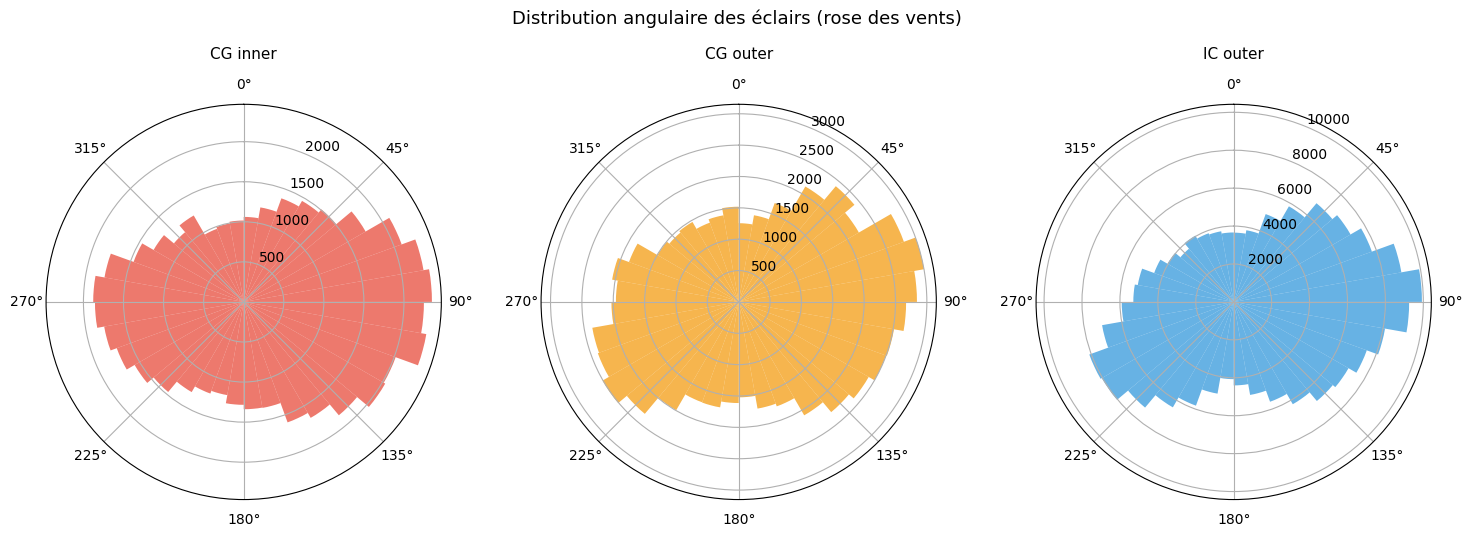

In [35]:
# %%
# Chunk 2 — Distribution angulaire par catégorie (rose des vents)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), subplot_kw=dict(projection='polar'))

configs = [
    ("CG inner", (df_raw["type"] == "CG") & (df_raw["zone"] == "inner"), "#e74c3c"),
    ("CG outer", (df_raw["type"] == "CG") & (df_raw["zone"] == "outer"), "#f39c12"),
    ("IC outer", (df_raw["type"] == "IC") & (df_raw["zone"] == "outer"), "#3498db"),
]

for ax, (label, mask, color) in zip(axes, configs):
    az_rad = np.radians(df_raw.loc[mask, "azimuth"].dropna())
    ax.hist(az_rad, bins=36, color=color, alpha=0.75)
    ax.set_title(label, pad=14, fontsize=11)
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

plt.suptitle("Distribution angulaire des éclairs (rose des vents)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()
# → Si uniforme : pas de secteur privilégié globalement
# → Si concentré dans un secteur : les orages arrivent souvent d'une direction

Corrélation dispersion angulaire ↔ durée alerte : 0.454
count    1682.0
mean       38.2
std        32.9
min        -0.0
25%        11.0
50%        29.4
75%        58.7
max       184.9
Name: az_circ_std_alert, dtype: float64


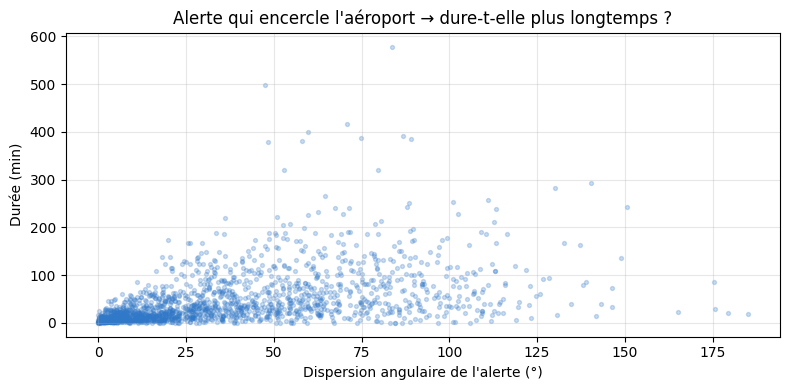

In [36]:
# %%
# Chunk 3 — Dispersion angulaire par alerte : lien avec la durée ?

def circular_std(azimuths_deg):
    """Écart-type circulaire (en degrés). Varie entre 0° (concentré) et ~81° (uniforme)."""
    if len(azimuths_deg) < 2:
        return np.nan
    rad = np.radians(azimuths_deg)
    R = np.sqrt(np.mean(np.cos(rad))**2 + np.mean(np.sin(rad))**2)
    return np.degrees(np.sqrt(-2 * np.log(np.clip(R, 1e-10, 1))))

az_disp = (
    df_raw[df_raw["airport_alert_id"].notna()]
    .groupby(["airport", "airport_alert_id"])["azimuth"]
    .apply(circular_std)
    .reset_index(name="az_circ_std_alert")
)

az_disp = az_disp.merge(
    df_alerts[["airport", "airport_alert_id", "duration"]],
    on=["airport", "airport_alert_id"], how="left"
)

corr_disp = az_disp["az_circ_std_alert"].corr(az_disp["duration"])
print(f"Corrélation dispersion angulaire ↔ durée alerte : {corr_disp:.3f}")
print(az_disp["az_circ_std_alert"].describe().round(1))

plt.figure(figsize=(8, 4))
plt.scatter(az_disp["az_circ_std_alert"], az_disp["duration"],
            alpha=0.25, s=8, color="#3078c8")
plt.xlabel("Dispersion angulaire de l'alerte (°)")
plt.ylabel("Durée (min)")
plt.title("Alerte qui encercle l'aéroport → dure-t-elle plus longtemps ?")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Corrélation déplacement angulaire ↔ durée : 0.248
count    1133.0
mean       50.4
std        47.8
min         0.0
25%        13.3
50%        33.5
75%        75.8
max       179.7
Name: az_shift_deg, dtype: float64


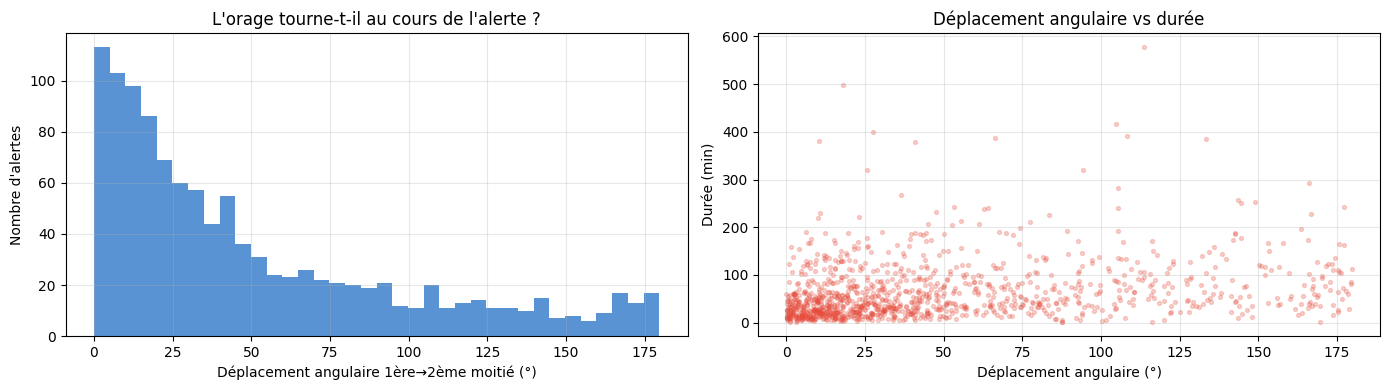

In [37]:
# %%
# Chunk 4 — L'orage se déplace-t-il au cours de l'alerte ?
# Compare l'azimuth moyen 1ère moitié vs 2ème moitié des CG inner

def mean_circular_angle(azimuths_deg):
    rad = np.radians(azimuths_deg)
    return np.degrees(np.arctan2(np.mean(np.sin(rad)), np.mean(np.cos(rad)))) % 360

def angular_diff(a1, a2):
    return abs((a2 - a1 + 180) % 360 - 180)

cg_inner_raw = df_raw[
    (df_raw["type"] == "CG") &
    (df_raw["zone"] == "inner") &
    (df_raw["airport_alert_id"].notna())
].copy()

def directional_shift(group):
    group = group.sort_values("date")
    n = len(group)
    if n < 4:
        return np.nan
    mid = n // 2
    az1 = mean_circular_angle(group.iloc[:mid]["azimuth"].values)
    az2 = mean_circular_angle(group.iloc[mid:]["azimuth"].values)
    return angular_diff(az1, az2)

shift = (
    cg_inner_raw.groupby(["airport", "airport_alert_id"])
    .apply(directional_shift, include_groups=False)
    .reset_index(name="az_shift_deg")
)

shift = shift.merge(
    df_alerts[["airport", "airport_alert_id", "duration"]],
    on=["airport", "airport_alert_id"], how="left"
)

corr_shift = shift["az_shift_deg"].corr(shift["duration"])
print(f"Corrélation déplacement angulaire ↔ durée : {corr_shift:.3f}")
print(shift["az_shift_deg"].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(shift["az_shift_deg"].dropna(), bins=36, alpha=0.8, color="#3078c8")
axes[0].set_xlabel("Déplacement angulaire 1ère→2ème moitié (°)")
axes[0].set_ylabel("Nombre d'alertes")
axes[0].set_title("L'orage tourne-t-il au cours de l'alerte ?")
axes[0].grid(alpha=0.3)

axes[1].scatter(shift["az_shift_deg"], shift["duration"],
                alpha=0.25, s=8, color="#e74c3c")
axes[1].set_xlabel("Déplacement angulaire (°)")
axes[1].set_ylabel("Durée (min)")
axes[1].set_title("Déplacement angulaire vs durée")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [38]:
# %%
# Chunk 5 — Test rapide : azimuth apporte-t-il de l'info au-delà de dist_min ?

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

merged = (
    az_disp.dropna()
    .merge(
        df_raw[df_raw["airport_alert_id"].notna()]
        .groupby(["airport", "airport_alert_id"])["dist"]
        .min()
        .reset_index(name="min_dist"),
        on=["airport", "airport_alert_id"], how="left"
    )
    .dropna(subset=["min_dist", "az_circ_std_alert", "duration"])
)

# Proxy label : alerte longue (> médiane) = 1
med = merged["duration"].median()
merged["y"] = (merged["duration"] > med).astype(int)

sc = StandardScaler()
X1 = sc.fit_transform(merged[["min_dist"]])
X2 = sc.fit_transform(merged[["min_dist", "az_circ_std_alert"]])

auc1 = roc_auc_score(merged["y"],
    LogisticRegression().fit(X1, merged["y"]).predict_proba(X1)[:, 1])
auc2 = roc_auc_score(merged["y"],
    LogisticRegression().fit(X2, merged["y"]).predict_proba(X2)[:, 1])

print(f"AUC dist_min seul                    : {auc1:.4f}")
print(f"AUC dist_min + az_circ_std_alert     : {auc2:.4f}")
print(f"Gain                                 : {auc2 - auc1:+.4f}")
print()
print("Interprétation :")
print("  gain > 0.01  → azimuth porte de l'info non redondante, vaut la peine d'être dans le modèle")
print("  gain ≈ 0     → dist_min capture déjà tout, azimuth redondant au niveau alerte")
print("  (Note : le test ici est au niveau alerte ; l'azimuth peut quand même aider")
print("   au niveau instant de décision via des features de tendance angulaire)")

AUC dist_min seul                    : 0.8008
AUC dist_min + az_circ_std_alert     : 0.8243
Gain                                 : +0.0235

Interprétation :
  gain > 0.01  → azimuth porte de l'info non redondante, vaut la peine d'être dans le modèle
  gain ≈ 0     → dist_min capture déjà tout, azimuth redondant au niveau alerte
  (Note : le test ici est au niveau alerte ; l'azimuth peut quand même aider
   au niveau instant de décision via des features de tendance angulaire)


In [39]:
df = pd.read_csv("/home/onyxia/work/Dataverse/Dataverse/output/silence_dataset.csv")

    min_since_cg      p_y1      n
0              1  0.140159  18743
1              2  0.220349  11922
2              3  0.294177   8930
3              4  0.361696   7263
4              5  0.422959   6211
5              6  0.474017   5542
6              7  0.519478   5057
7              8  0.561205   4681
8              9  0.595557   4411
9             10  0.632403   4154
10            11  0.663216   3961
11            12  0.690045   3807
12            13  0.717564   3661
13            14  0.741462   3543
14            15  0.766560   3427

P(y=1) à 1 min  : 0.140
P(y=1) à 5 min  : 0.423
P(y=1) à 10 min : 0.632
P(y=1) à 20 min : 0.857


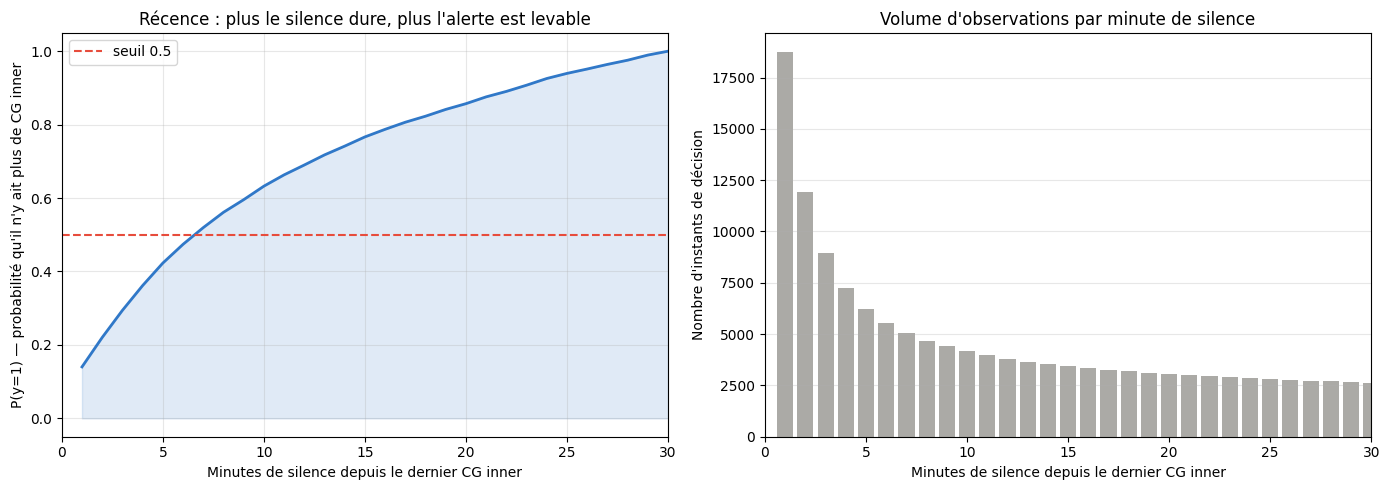

In [40]:
# %%
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

SILENCE_PATH = "/home/onyxia/work/Dataverse/Dataverse/output/silence_dataset.csv"
OUTPUT_PATH = "/home/onyxia/work/Dataverse/Dataverse/output"

df = pd.read_csv(SILENCE_PATH)

# Arrondir à la minute entière pour grouper
df["min_since_cg"] = df["minutes_since_reference_cg"].round(0).astype(int)

# Probabilité de y=1 par minute de silence
curve = (
    df.groupby("min_since_cg")["y"]
    .agg(["mean", "count"])
    .reset_index()
    .rename(columns={"mean": "p_y1", "count": "n"})
)

# Garder seulement les minutes avec assez d'observations
curve = curve[curve["n"] >= 50]

print(curve.head(15).to_string())
print(f"\nP(y=1) à 1 min  : {curve[curve['min_since_cg']==1]['p_y1'].values[0]:.3f}")
print(f"P(y=1) à 5 min  : {curve[curve['min_since_cg']==5]['p_y1'].values[0]:.3f}")
print(f"P(y=1) à 10 min : {curve[curve['min_since_cg']==10]['p_y1'].values[0]:.3f}")
print(f"P(y=1) à 20 min : {curve[curve['min_since_cg']==20]['p_y1'].values[0]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Courbe principale
axes[0].plot(curve["min_since_cg"], curve["p_y1"], color="#3078c8", linewidth=2)
axes[0].axhline(0.5, color="#e74c3c", linestyle="--", label="seuil 0.5")
axes[0].fill_between(curve["min_since_cg"], curve["p_y1"], alpha=0.15, color="#3078c8")
axes[0].set_xlabel("Minutes de silence depuis le dernier CG inner")
axes[0].set_ylabel("P(y=1) — probabilité qu'il n'y ait plus de CG inner")
axes[0].set_title("Récence : plus le silence dure, plus l'alerte est levable")
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_xlim(0, 30)

# Volume d'observations par minute
axes[1].bar(curve["min_since_cg"], curve["n"], color="#888780", alpha=0.7)
axes[1].set_xlabel("Minutes de silence depuis le dernier CG inner")
axes[1].set_ylabel("Nombre d'instants de décision")
axes[1].set_title("Volume d'observations par minute de silence")
axes[1].grid(alpha=0.3, axis="y")
axes[1].set_xlim(0, 30)

plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}/recence_y1_vs_silence.png", dpi=130, bbox_inches="tight")
plt.show()

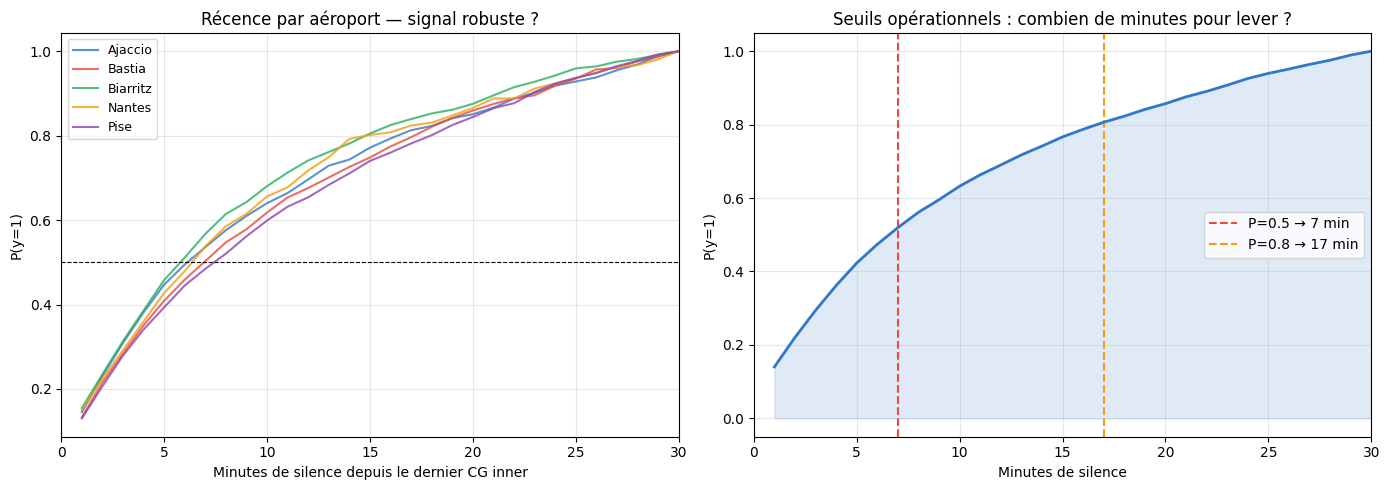

In [41]:
# %%
# Par aéroport — robustesse du signal

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {
    "Ajaccio": "#3078c8", "Bastia": "#e74c3c",
    "Biarritz": "#27ae60", "Nantes": "#f39c12", "Pise": "#8e44ad"
}

for airport, g in df.groupby("airport"):
    c = (
        g.assign(min_since_cg=g["minutes_since_reference_cg"].round(0).astype(int))
        .groupby("min_since_cg")["y"]
        .agg(["mean", "count"])
        .reset_index()
    )
    c = c[c["count"] >= 20]
    axes[0].plot(c["min_since_cg"], c["mean"],
                 label=airport, color=colors[airport], linewidth=1.5, alpha=0.8)

axes[0].axhline(0.5, color="black", linestyle="--", linewidth=0.8)
axes[0].set_xlim(0, 30)
axes[0].set_xlabel("Minutes de silence depuis le dernier CG inner")
axes[0].set_ylabel("P(y=1)")
axes[0].set_title("Récence par aéroport — signal robuste ?")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Seuils opérationnels
for seuil, color, label in [(0.5, "#e74c3c", "P=0.5"), (0.8, "#f39c12", "P=0.8")]:
    above = curve[curve["p_y1"] >= seuil]
    if len(above) > 0:
        t_cross = above["min_since_cg"].iloc[0]
        axes[1].axvline(t_cross, color=color, linestyle="--",
                        label=f"{label} → {t_cross} min")

axes[1].plot(curve["min_since_cg"], curve["p_y1"], color="#3078c8", linewidth=2)
axes[1].fill_between(curve["min_since_cg"], curve["p_y1"], alpha=0.15, color="#3078c8")
axes[1].set_xlim(0, 30)
axes[1].set_xlabel("Minutes de silence")
axes[1].set_ylabel("P(y=1)")
axes[1].set_title("Seuils opérationnels : combien de minutes pour lever ?")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}/recence_par_airport.png", dpi=130, bbox_inches="tight")
plt.show()

In [42]:
# %%
# Analyse : les alertes avec CG très proches (<3km) sont-elles plus dures à lever ?

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/home/onyxia/work/Dataverse/Dataverse/output/silence_dataset.csv")
df["min_since_cg"] = df["minutes_since_reference_cg"].round(0).astype(int)

# Identifier les alertes qui ont eu au moins un CG < 3km
# dist_min = distance minimale observée sur tout l'historique jusqu'à t
CLOSE_KM = 3.0

df["had_close_cg"] = df["dist_min"] < CLOSE_KM

print("Répartition alertes avec/sans CG < 3km :")
print(df.groupby("had_close_cg")["alert_group"].nunique())
print(f"\nSoit {100*df['had_close_cg'].mean():.1f}% des instants de décision"
      f" proviennent d'alertes avec au moins un CG < {CLOSE_KM}km")

Répartition alertes avec/sans CG < 3km :
had_close_cg
False    2553
True      520
Name: alert_group, dtype: int64

Soit 24.7% des instants de décision proviennent d'alertes avec au moins un CG < 3.0km


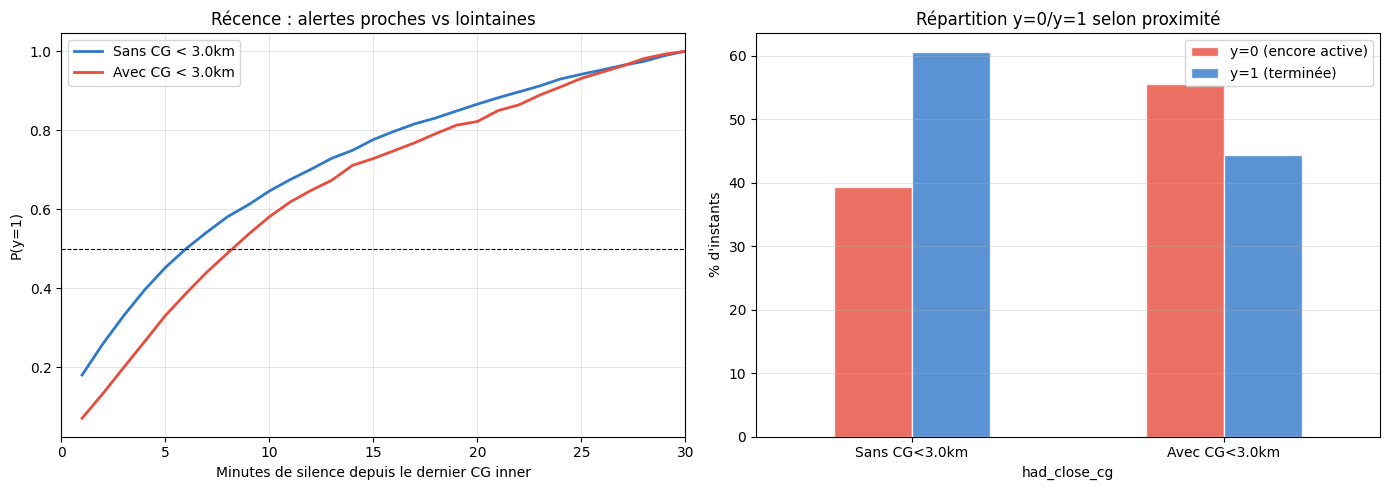

In [43]:
# %%
# Courbe P(y=1) vs silence — comparaison alertes proches vs lointaines

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for had_close, label, color in [
    (False, f"Sans CG < {CLOSE_KM}km", "#3078c8"),
    (True,  f"Avec CG < {CLOSE_KM}km", "#e74c3c"),
]:
    sub = df[df["had_close_cg"] == had_close]
    curve = (
        sub.groupby("min_since_cg")["y"]
        .agg(["mean", "count"])
        .reset_index()
        .rename(columns={"mean": "p_y1", "count": "n"})
    )
    curve = curve[curve["n"] >= 30]
    axes[0].plot(curve["min_since_cg"], curve["p_y1"],
                 label=label, color=color, linewidth=2)

axes[0].axhline(0.5, color="black", linestyle="--", linewidth=0.8)
axes[0].set_xlim(0, 30)
axes[0].set_xlabel("Minutes de silence depuis le dernier CG inner")
axes[0].set_ylabel("P(y=1)")
axes[0].set_title("Récence : alertes proches vs lointaines")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Distribution de y selon la proximité
counts = df.groupby(["had_close_cg", "y"]).size().unstack(fill_value=0)
counts_pct = counts.div(counts.sum(axis=1), axis=0) * 100
counts_pct.plot(kind="bar", ax=axes[1], color=["#e74c3c", "#3078c8"],
                alpha=0.8, edgecolor="white")
axes[1].set_xticklabels([f"Sans CG<{CLOSE_KM}km", f"Avec CG<{CLOSE_KM}km"],
                          rotation=0)
axes[1].set_ylabel("% d'instants")
axes[1].set_title("Répartition y=0/y=1 selon proximité")
axes[1].legend(["y=0 (encore active)", "y=1 (terminée)"])
axes[1].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("/home/onyxia/work/Dataverse/Dataverse/output/close_cg_analysis.png",
            dpi=130, bbox_inches="tight")
plt.show()

In [44]:
# %%
# Combien de minutes faut-il pour dépasser P(y=1) > 0.8
# selon que l'alerte a eu des CG proches ou non ?

print("=== Seuils opérationnels selon la dangerosité ===\n")

for had_close, label in [(False, f"Sans CG < {CLOSE_KM}km"),
                          (True,  f"Avec CG < {CLOSE_KM}km")]:
    sub = df[df["had_close_cg"] == had_close]
    curve = (
        sub.groupby("min_since_cg")["y"]
        .agg(["mean", "count"])
        .reset_index()
        .rename(columns={"mean": "p_y1", "count": "n"})
    )
    curve = curve[curve["n"] >= 30]

    for seuil in [0.5, 0.8]:
        above = curve[curve["p_y1"] >= seuil]
        if len(above) > 0:
            t = above["min_since_cg"].iloc[0]
            print(f"{label} — P(y=1) > {seuil} atteint à : {t} min de silence")
        else:
            print(f"{label} — P(y=1) > {seuil} : jamais atteint sur 30 min")
    print()

=== Seuils opérationnels selon la dangerosité ===

Sans CG < 3.0km — P(y=1) > 0.5 atteint à : 6 min de silence
Sans CG < 3.0km — P(y=1) > 0.8 atteint à : 17 min de silence

Avec CG < 3.0km — P(y=1) > 0.5 atteint à : 9 min de silence
Avec CG < 3.0km — P(y=1) > 0.8 atteint à : 19 min de silence



In [45]:
# %%
# Direction de l'orage pendant le silence — est-ce que l'azimuth aide ?
# On regarde si la direction/dispersion angulaire des éclairs pendant le silence
# est liée à y (fin d'alerte ou non)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/home/onyxia/work/Dataverse/Dataverse/output/silence_dataset.csv")
df_raw = pd.read_csv("/home/onyxia/work/Dataverse/Dataverse/data/segment_alerts_all_airports_train.csv")
df_raw["date"] = pd.to_datetime(df_raw["date"], utc=True)
df_raw["type"] = np.where(df_raw["icloud"].fillna(False), "IC", "CG")
df_raw["zone"] = np.where(df_raw["dist"] < 20, "inner", "outer")

print(f"Silence dataset : {df.shape}")

Silence dataset : (139226, 63)


In [46]:
# %%
# Courbe ROC + enveloppe convexe + interprétation test_metrics

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull

BASE = "/home/onyxia/work/Dataverse/Dataverse"
ROC_DIR = f"{BASE}/output/baseline_results_A"

# Chargement
roc_df = pd.read_csv(f"{ROC_DIR}/roc_points.csv")
metrics_df = pd.read_csv(f"{ROC_DIR}/test_metrics.csv")

print("Modèles disponibles dans roc_points :", roc_df["model"].unique().tolist())
print("Shape roc_df :", roc_df.shape)

Modèles disponibles dans roc_points : ['logistic', 'knn', 'cart', 'random_forest', 'bagging_tree', 'adaboost_tree', 'xgboost']
Shape roc_df : (40223, 4)


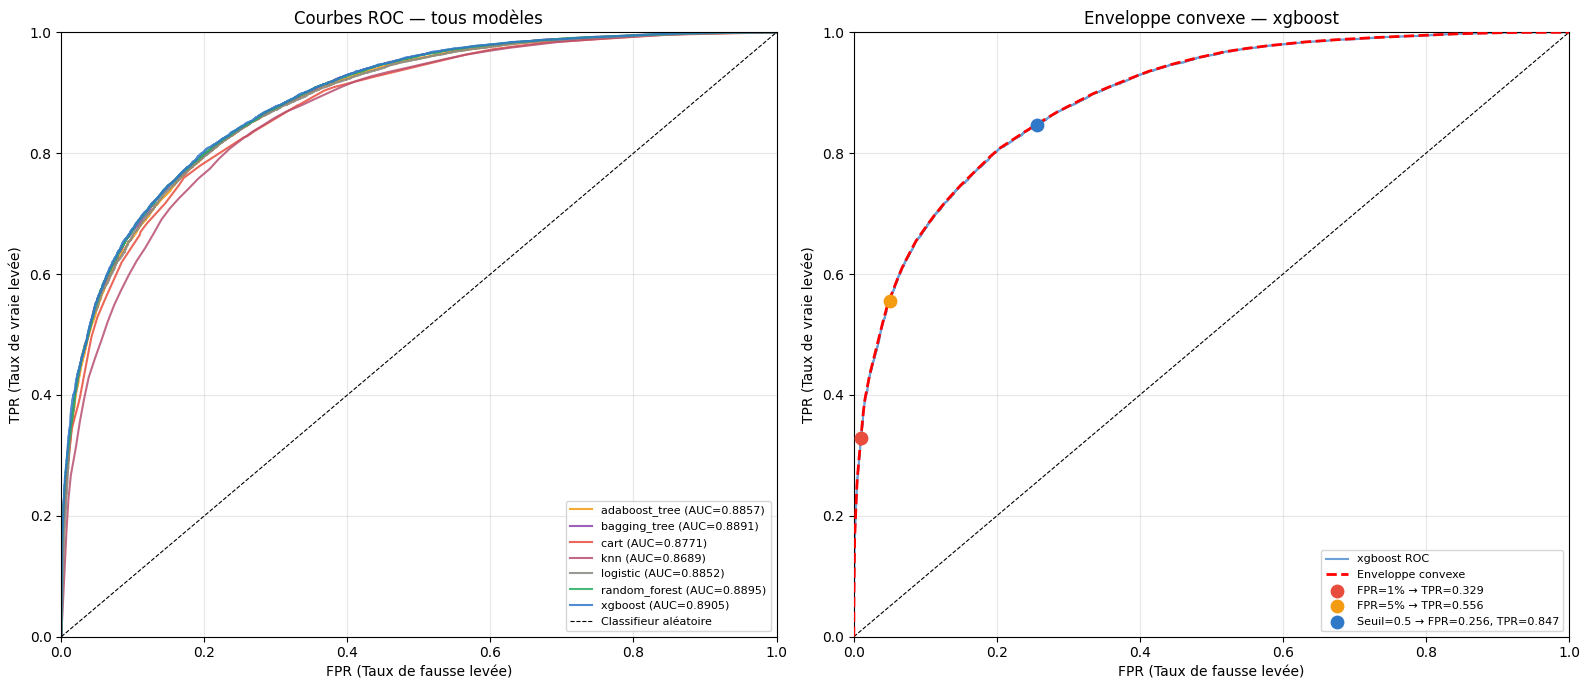

In [47]:
# %%
# Courbe ROC complète pour tous les modèles + enveloppe convexe

"""
ENVELOPPE CONVEXE DE LA COURBE ROC
-----------------------------------
Définition : c'est la plus petite surface convexe contenant la courbe ROC.
Elle représente l'ensemble des classifieurs atteignables par mélange aléatoire
(randomisation) entre deux points de la courbe.

Propriété clé (cours section 5.3) :
- Tout point SOUS l'enveloppe convexe est dominé : il existe une combinaison
  de deux classifieurs qui fait strictement mieux à FPR égal.
- Un classifieur optimal doit opérer SUR l'enveloppe convexe.
- La pente de l'enveloppe en un point = rapport des coûts C(FP)/C(FN).
  Pour choisir le seuil optimal selon la métrique métier, on cherche le point
  de l'enveloppe dont la pente correspond au rapport de coûts souhaité.

LECTURE DES 3 POINTS DE FONCTIONNEMENT (meilleur modèle = XGBoost, AUC=0.8905) :

Point rouge — FPR=1%, TPR=0.329 :
  Seuil de sécurité forte. On n'accepte qu'1% de fausses levées (lever l'alerte
  alors qu'un CG inner arrive encore). En contrepartie, on ne détecte que 33%
  des fins d'alerte réelles — très conservateur, adapté aux situations
  où une fausse levée est une erreur critique.

Point orange — FPR=5%, TPR=0.556 :
  Compromis opérationnel. 5% de fausses levées acceptées, on détecte 56%
  des fins d'alerte. Point de fonctionnement réaliste pour la production,
  à calibrer selon la métrique fournie par Météorage.

Point bleu — seuil=0.5, FPR=0.256, TPR=0.847 :
  Seuil par défaut sklearn. On lève correctement 85% des alertes terminées
  mais au prix de 26% de fausses levées — 1 levée sur 4 serait une erreur
  de sécurité. Ce seuil est inutilisable en production.

CONCLUSION :
  L'enveloppe convexe colle quasiment à la courbe ROC de XGBoost — la courbe
  est déjà quasi-convexe, il n'y a pas de zones creuses à corriger par
  randomisation. Le choix du seuil opérationnel dépendra du rapport de coûts
  C(FP)/C(FN) défini par la métrique Météorage.
  En contexte sécurité aéroportuaire, C(FP) >> C(FN) — une fausse levée
  est bien plus grave qu'une non-levée tardive — ce qui oriente vers
  un point de fonctionnement proche du point rouge (FPR faible).
"""

COLORS = {
    "xgboost": "#3078c8",
    "random_forest": "#27ae60",
    "bagging_tree": "#8e44ad",
    "adaboost_tree": "#f39c12",
    "logistic": "#888780",
    "cart": "#e74c3c",
    "knn": "#b85070",
}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Graphe gauche : toutes les courbes ROC ──────────────────────────
for model, g in roc_df.groupby("model"):
    g = g.sort_values("fpr")
    axes[0].plot(g["fpr"], g["tpr"],
                 label=f"{model} (AUC={metrics_df[metrics_df['model']==model]['auc'].values[0]:.4f})",
                 color=COLORS.get(model, "gray"), linewidth=1.5, alpha=0.85)

axes[0].plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Classifieur aléatoire")
axes[0].set_xlabel("FPR (Taux de fausse levée)")
axes[0].set_ylabel("TPR (Taux de vraie levée)")
axes[0].set_title("Courbes ROC — tous modèles")
axes[0].legend(fontsize=8, loc="lower right")
axes[0].grid(alpha=0.3)
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1)

# ── Graphe droite : enveloppe convexe sur le meilleur modèle ────────
best_model = metrics_df.sort_values("auc", ascending=False).iloc[0]["model"]
g_best = roc_df[roc_df["model"] == best_model].sort_values("fpr").reset_index(drop=True)

axes[1].plot(g_best["fpr"], g_best["tpr"],
             color=COLORS.get(best_model, "blue"),
             linewidth=1.5, label=f"{best_model} ROC", alpha=0.7)

# Calcul enveloppe convexe
points = np.column_stack([g_best["fpr"].values, g_best["tpr"].values])
points = np.vstack([[0, 0], points, [1, 1]])
hull = ConvexHull(points)
hull_pts = points[hull.vertices]
hull_pts = hull_pts[hull_pts[:, 1] >= hull_pts[:, 0]]
hull_pts = hull_pts[hull_pts[:, 0].argsort()]

axes[1].plot(hull_pts[:, 0], hull_pts[:, 1],
             "r--", linewidth=2, label="Enveloppe convexe", zorder=5)

# Points de fonctionnement
row = metrics_df[metrics_df["model"] == best_model].iloc[0]
axes[1].scatter([0.01], [row["tpr_at_fpr_1pct"]],
                color="#e74c3c", s=80, zorder=6,
                label=f"FPR=1% → TPR={row['tpr_at_fpr_1pct']:.3f}")
axes[1].scatter([0.05], [row["tpr_at_fpr_5pct"]],
                color="#f39c12", s=80, zorder=6,
                label=f"FPR=5% → TPR={row['tpr_at_fpr_5pct']:.3f}")
axes[1].scatter([row["fpr_at_threshold_0.5"]], [row["tpr_at_threshold_0.5"]],
                color="#3078c8", s=80, zorder=6,
                label=f"Seuil=0.5 → FPR={row['fpr_at_threshold_0.5']:.3f}, "
                      f"TPR={row['tpr_at_threshold_0.5']:.3f}")

axes[1].plot([0, 1], [0, 1], "k--", linewidth=0.8)
axes[1].set_xlabel("FPR (Taux de fausse levée)")
axes[1].set_ylabel("TPR (Taux de vraie levée)")
axes[1].set_title(f"Enveloppe convexe — {best_model}")
axes[1].legend(fontsize=8, loc="lower right")
axes[1].grid(alpha=0.3)
axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig(f"{BASE}/output/roc_enveloppe_convexe.png", dpi=130, bbox_inches="tight")
plt.show()

In [48]:
# %%
# Interprétation test_metrics

print("=== INTERPRÉTATION TEST METRICS ===\n")
print(f"{'Modèle':<15} {'AUC':>6} {'TPR@FPR1%':>10} {'TPR@FPR5%':>10} {'FPR@seuil0.5':>13} {'TPR@seuil0.5':>13}")
print("-" * 72)

for _, row in metrics_df.sort_values("auc", ascending=False).iterrows():
    print(f"{row['model']:<15} {row['auc']:>6.4f} "
          f"{row['tpr_at_fpr_1pct']:>10.3f} "
          f"{row['tpr_at_fpr_5pct']:>10.3f} "
          f"{row['fpr_at_threshold_0.5']:>13.3f} "
          f"{row['tpr_at_threshold_0.5']:>13.3f}")

print("\n=== LECTURE DES MÉTRIQUES ===\n")
best = metrics_df.sort_values("auc", ascending=False).iloc[0]
print(f"Meilleur modèle : {best['model']} (AUC = {best['auc']:.4f})\n")

print(f"Au seuil 0.5 :")
print(f"  TPR = {best['tpr_at_threshold_0.5']:.3f} → "
      f"on lève correctement {best['tpr_at_threshold_0.5']*100:.1f}% des alertes terminées")
print(f"  FPR = {best['fpr_at_threshold_0.5']:.3f} → "
      f"on lève à tort {best['fpr_at_threshold_0.5']*100:.1f}% des alertes encore actives")
print(f"  TP={int(best['tp_at_0.5'])}, FP={int(best['fp_at_0.5'])}, "
      f"TN={int(best['tn_at_0.5'])}, FN={int(best['fn_at_0.5'])}\n")

print(f"À FPR contraint à 1% (seuil de sécurité forte) :")
print(f"  TPR = {best['tpr_at_fpr_1pct']:.3f} → "
      f"on détecte {best['tpr_at_fpr_1pct']*100:.1f}% des fins d'alerte")
print(f"  → On manque {(1-best['tpr_at_fpr_1pct'])*100:.1f}% des fins d'alerte réelles\n")

print(f"À FPR contraint à 5% (compromis opérationnel) :")
print(f"  TPR = {best['tpr_at_fpr_5pct']:.3f} → "
      f"on détecte {best['tpr_at_fpr_5pct']*100:.1f}% des fins d'alerte")

print("\n=== RAPPEL INTERPRÉTATION MÉTIER ===")
print("FPR = taux de fausse levée = lever l'alerte alors qu'un CG inner arrive encore")
print("      → erreur de SÉCURITÉ, la plus grave opérationnellement")
print("TPR = taux de vraie levée  = lever l'alerte quand c'est effectivement fini")
print("      → gain opérationnel, réduction du temps d'alerte inutile")
print("\nL'enveloppe convexe montre le front de Pareto de ce compromis :")
print("→ tout point sur l'enveloppe est optimal pour un certain rapport coût FP/FN")
print("→ tout point sous l'enveloppe est dominé et ne devrait pas être utilisé")

=== INTERPRÉTATION TEST METRICS ===

Modèle             AUC  TPR@FPR1%  TPR@FPR5%  FPR@seuil0.5  TPR@seuil0.5
------------------------------------------------------------------------
xgboost         0.8905      0.329      0.556         0.256         0.847
random_forest   0.8895      0.315      0.555         0.204         0.803
bagging_tree    0.8891      0.316      0.557         0.254         0.842
adaboost_tree   0.8857      0.294      0.543         0.249         0.839
logistic        0.8852      0.283      0.544         0.184         0.778
cart            0.8771      0.280      0.497         0.194         0.779
knn             0.8689      0.177      0.461         0.267         0.835

=== LECTURE DES MÉTRIQUES ===

Meilleur modèle : xgboost (AUC = 0.8905)

Au seuil 0.5 :
  TPR = 0.847 → on lève correctement 84.7% des alertes terminées
  FPR = 0.256 → on lève à tort 25.6% des alertes encore actives
  TP=13393, FP=3079, TN=8964, FN=2417

À FPR contraint à 1% (seuil de sécurité forte) :


In [49]:
"""
LECTURE DU GRAPHE DROITE
-------------------------
Une seule courbe ROC — XGBoost (AUC=0.8905) — avec trois éléments superposés :

1. COURBE BLEUE — courbe ROC de XGBoost
   Chaque point correspond à un seuil de décision différent.
   En faisant varier ce seuil de 1 à 0, on trace tous les couples
   (FPR, TPR) atteignables par le modèle.

2. COURBE ROUGE POINTILLÉE — enveloppe convexe
   Elle représente l'ensemble des classifieurs atteignables par mélange
   aléatoire entre deux seuils (cours section 5.3).
   Tout point sous l'enveloppe est dominé — on peut faire mieux.
   Ici elle colle à la courbe ROC : XGBoost est déjà bien calibré,
   sans zones non-convexes. C'est un bon signe.

3. TROIS POINTS DE FONCTIONNEMENT OPÉRATIONNELS :

   Point rouge  — FPR=1%, TPR=0.329 :
     Seuil de sécurité forte. On n'accepte qu'1% de fausses levées
     (lever l'alerte alors qu'un CG inner arrive encore).
     En contrepartie on ne détecte que 33% des fins d'alerte réelles.
     Très conservateur — adapté si une fausse levée est inacceptable.

   Point orange — FPR=5%, TPR=0.556 :
     Compromis opérationnel. 5% de fausses levées acceptées,
     on détecte 56% des fins d'alerte réelles.
     Point de fonctionnement réaliste pour la production.

   Point bleu   — seuil=0.5, FPR=0.256, TPR=0.847 :
     Seuil par défaut sklearn. On lève correctement 85% des alertes
     terminées mais au prix de 26% de fausses levées.
     1 levée sur 4 serait une erreur de sécurité — inutilisable
     en production aéroportuaire.

CONCLUSION :
   Le choix du point de fonctionnement dépend du rapport de coûts
   C(FP)/C(FN) défini par la métrique Météorage.
   En contexte sécurité, C(FP) >> C(FN) — une fausse levée est
   bien plus grave qu'une non-levée tardive — ce qui oriente vers
   un point proche du point rouge (FPR très faible).
"""

"\nLECTURE DU GRAPHE DROITE\n-------------------------\nUne seule courbe ROC — XGBoost (AUC=0.8905) — avec trois éléments superposés :\n\n1. COURBE BLEUE — courbe ROC de XGBoost\n   Chaque point correspond à un seuil de décision différent.\n   En faisant varier ce seuil de 1 à 0, on trace tous les couples\n   (FPR, TPR) atteignables par le modèle.\n\n2. COURBE ROUGE POINTILLÉE — enveloppe convexe\n   Elle représente l'ensemble des classifieurs atteignables par mélange\n   aléatoire entre deux seuils (cours section 5.3).\n   Tout point sous l'enveloppe est dominé — on peut faire mieux.\n   Ici elle colle à la courbe ROC : XGBoost est déjà bien calibré,\n   sans zones non-convexes. C'est un bon signe.\n\n3. TROIS POINTS DE FONCTIONNEMENT OPÉRATIONNELS :\n\n   Point rouge  — FPR=1%, TPR=0.329 :\n     Seuil de sécurité forte. On n'accepte qu'1% de fausses levées\n     (lever l'alerte alors qu'un CG inner arrive encore).\n     En contrepartie on ne détecte que 33% des fins d'alerte réelles.

In [50]:
# %%
# Analyse LRE — éclairs à moins de 3km (tous types)
# Question : après une accalmie, est-ce que les LRE peuvent revenir ?
# Si oui → seuil theta plus élevé justifié pour ces alertes

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

SILENCE_PATH = "/home/onyxia/work/Dataverse/Dataverse/output/silence_dataset.csv"
RAW_PATH = "/home/onyxia/work/Dataverse/Dataverse/data/segment_alerts_all_airports_train.csv"

df = pd.read_csv(SILENCE_PATH)
df_raw = pd.read_csv(RAW_PATH)
df_raw["date"] = pd.to_datetime(df_raw["date"], utc=True)
df_raw["type"] = np.where(df_raw["icloud"].fillna(False), "IC", "CG")
df_raw["zone"] = np.where(df_raw["dist"] < 20, "inner", "outer")

print(f"Silence dataset : {df.shape}")
print(f"Dataset brut    : {df_raw.shape}")

Silence dataset : (139226, 63)
Dataset brut    : (507071, 15)


In [51]:
# %%
# Chunk 1 — Combien d'alertes ont des LRE (éclairs < 3km) ?
# Et combien en ont plusieurs ?

LRE_DIST = 3.0

lre_per_alert = (
    df_raw[df_raw["airport_alert_id"].notna()]
    .assign(is_lre=lambda x: x["dist"] < LRE_DIST)
    .groupby(["airport", "airport_alert_id"])["is_lre"]
    .agg(["sum", "max"])
    .reset_index()
    .rename(columns={"sum": "n_lre", "max": "has_lre"})
)

print("=== Distribution du nombre de LRE par alerte ===\n")
print(lre_per_alert["n_lre"].describe().round(2))
print(f"\nAlertes sans LRE         : {(lre_per_alert['n_lre']==0).sum()}")
print(f"Alertes avec 1 LRE       : {(lre_per_alert['n_lre']==1).sum()}")
print(f"Alertes avec 2-5 LRE     : {((lre_per_alert['n_lre']>=2) & (lre_per_alert['n_lre']<=5)).sum()}")
print(f"Alertes avec > 5 LRE     : {(lre_per_alert['n_lre']>5).sum()}")
print(f"\nTotal alertes avec LRE   : {lre_per_alert['has_lre'].sum()} "
      f"({100*lre_per_alert['has_lre'].mean():.1f}%)")

=== Distribution du nombre de LRE par alerte ===

count    2627.00
mean        0.48
std         2.43
min         0.00
25%         0.00
50%         0.00
75%         0.00
max        64.00
Name: n_lre, dtype: float64

Alertes sans LRE         : 2268
Alertes avec 1 LRE       : 188
Alertes avec 2-5 LRE     : 112
Alertes avec > 5 LRE     : 59

Total alertes avec LRE   : 359 (13.7%)


In [52]:
# %%
# Chunk 2 — Est-ce que les LRE peuvent survenir APRÈS une accalmie ?
# On cherche les alertes où il y a eu un silence > X minutes
# puis un LRE est apparu ensuite (rebond dangereux)

SILENCE_THRESHOLD_MIN = 5  # silence de X minutes avant un LRE

alerts_with_lre = df_raw[
    df_raw["airport_alert_id"].notna() &
    (df_raw["dist"] < LRE_DIST)
][["airport", "airport_alert_id", "date"]].copy()

rebonds = []

for (airport, alert_id), group in df_raw[
    df_raw["airport_alert_id"].notna()
].groupby(["airport", "airport_alert_id"]):

    group = group.sort_values("date").reset_index(drop=True)
    lre_in_alert = group[group["dist"] < LRE_DIST]

    if len(lre_in_alert) == 0:
        continue

    for _, lre_row in lre_in_alert.iterrows():
        t_lre = lre_row["date"]

        # Éclairs dans les X minutes avant ce LRE
        window_start = t_lre - pd.Timedelta(minutes=SILENCE_THRESHOLD_MIN)
        events_before = group[
            (group["date"] > window_start) &
            (group["date"] < t_lre)
        ]

        # Si aucun événement dans la fenêtre → c'est un rebond après silence
        if len(events_before) == 0:
            rebonds.append({
                "airport": airport,
                "airport_alert_id": alert_id,
                "lre_date": t_lre,
                "lre_dist": lre_row["dist"],
                "lre_type": lre_row["type"],
                "silence_before_min": SILENCE_THRESHOLD_MIN,
            })

rebonds_df = pd.DataFrame(rebonds)
print(f"=== LRE apparus après {SILENCE_THRESHOLD_MIN} min de silence ===\n")
print(f"Nombre de rebonds détectés : {len(rebonds_df)}")
if len(rebonds_df) > 0:
    print(f"Alertes concernées         : {rebonds_df['airport_alert_id'].nunique()}")
    print(f"Par aéroport :")
    print(rebonds_df.groupby("airport").size().to_string())
    print(f"\nType des LRE rebonds :")
    print(rebonds_df["lre_type"].value_counts().to_string())

=== LRE apparus après 5 min de silence ===

Nombre de rebonds détectés : 97
Alertes concernées         : 85
Par aéroport :
airport
Ajaccio     21
Bastia      16
Biarritz    16
Nantes      11
Pise        33

Type des LRE rebonds :
lre_type
CG    97


In [53]:
# %%
# Chunk 3 — Pour différents seuils de silence, combien de rebonds ?
# On teste 1, 3, 5, 10 minutes de silence avant un LRE

print("=== Rebonds LRE selon le seuil de silence ===\n")
print(f"{'Silence min':>12} | {'Nb rebonds':>10} | {'Alertes':>8} | {'% alertes LRE':>14}")
print("-" * 50)

for seuil in [1, 2, 3, 5, 7, 10, 15, 20]:
    n_rebonds = 0
    alertes_rebond = set()

    for (airport, alert_id), group in df_raw[
        df_raw["airport_alert_id"].notna()
    ].groupby(["airport", "airport_alert_id"]):
        group = group.sort_values("date").reset_index(drop=True)
        lre_in_alert = group[group["dist"] < LRE_DIST]
        if len(lre_in_alert) == 0:
            continue
        for _, lre_row in lre_in_alert.iterrows():
            t_lre = lre_row["date"]
            window_start = t_lre - pd.Timedelta(minutes=seuil)
            events_before = group[
                (group["date"] > window_start) &
                (group["date"] < t_lre)
            ]
            if len(events_before) == 0:
                n_rebonds += 1
                alertes_rebond.add(alert_id)

    n_alertes_lre = lre_per_alert["has_lre"].sum()
    pct = 100 * len(alertes_rebond) / n_alertes_lre if n_alertes_lre > 0 else 0
    print(f"{seuil:>12} | {n_rebonds:>10} | {len(alertes_rebond):>8} | {pct:>13.1f}%")

=== Rebonds LRE selon le seuil de silence ===

 Silence min | Nb rebonds |  Alertes |  % alertes LRE
--------------------------------------------------
           1 |        384 |      212 |          59.1%
           2 |        220 |      163 |          45.4%
           3 |        148 |      121 |          33.7%
           5 |         97 |       85 |          23.7%
           7 |         82 |       75 |          20.9%
          10 |         65 |       60 |          16.7%
          15 |         51 |       49 |          13.6%
          20 |         38 |       37 |          10.3%


=== Impact LRE sur le silence dataset ===

P(y=1) selon présence de LRE :
          mean   count
has_lre               
False    0.649  104825
True     0.313   34401

=== Seuils opérationnels selon présence LRE ===

Sans LRE — P(y=1) > 0.5 atteint à : 6 min
Sans LRE — P(y=1) > 0.8 atteint à : 15 min

Avec LRE — P(y=1) > 0.5 atteint à : 12 min
Avec LRE — P(y=1) > 0.8 atteint à : 23 min



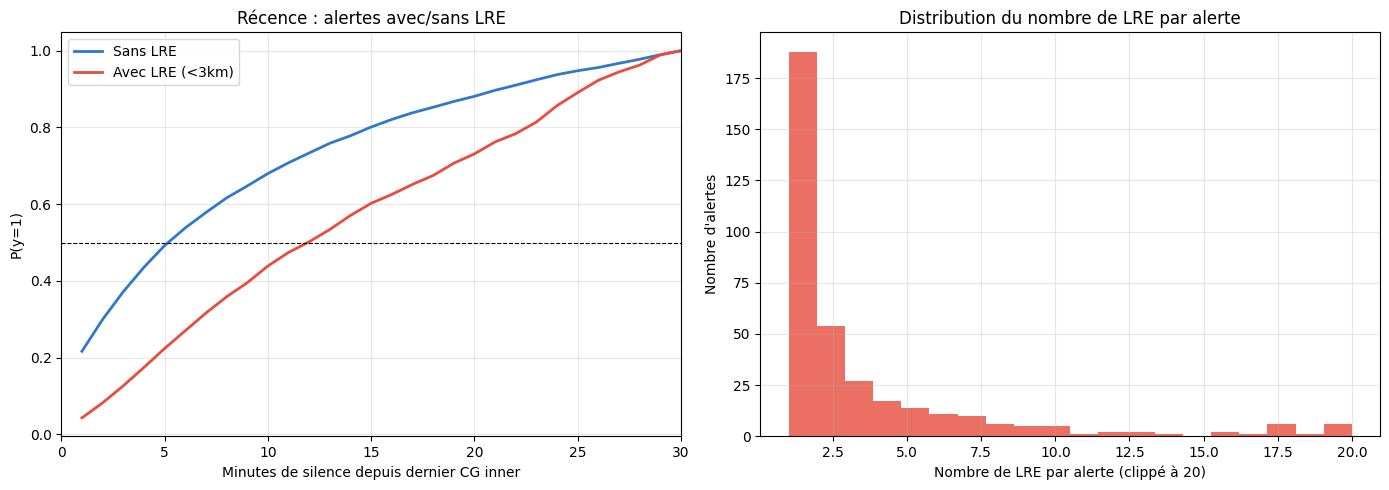

In [54]:
# %%
# Chunk 4 — Impact sur le silence dataset
# Parmi les instants y=0 dans le silence dataset,
# quelle proportion correspond à des cas où un LRE va survenir après ?

df["decision_time"] = pd.to_datetime(df["decision_time"], utc=True)

# Joindre les infos LRE au silence dataset
df = df.merge(
    lre_per_alert[["airport", "airport_alert_id", "n_lre", "has_lre"]],
    on=["airport", "airport_alert_id"],
    how="left"
)
df["has_lre"] = df["has_lre"].fillna(False)

print("=== Impact LRE sur le silence dataset ===\n")

# P(y=1) selon présence de LRE dans l'alerte
print("P(y=1) selon présence de LRE :")
print(df.groupby("has_lre")["y"].agg(["mean", "count"]).round(3))

# Courbe P(y=1) vs silence selon LRE
df["min_since_cg"] = df["minutes_since_reference_cg"].round(0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for has_lre, label, color in [
    (False, "Sans LRE", "#3078c8"),
    (True,  "Avec LRE (<3km)", "#e74c3c"),
]:
    sub = df[df["has_lre"] == has_lre]
    curve = (
        sub.groupby("min_since_cg")["y"]
        .agg(["mean", "count"])
        .reset_index()
        .rename(columns={"mean": "p_y1", "count": "n"})
    )
    curve = curve[curve["n"] >= 30]
    axes[0].plot(curve["min_since_cg"], curve["p_y1"],
                 label=label, color=color, linewidth=2)

axes[0].axhline(0.5, color="black", linestyle="--", linewidth=0.8)
axes[0].set_xlim(0, 30)
axes[0].set_xlabel("Minutes de silence depuis dernier CG inner")
axes[0].set_ylabel("P(y=1)")
axes[0].set_title("Récence : alertes avec/sans LRE")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Seuils opérationnels
print("\n=== Seuils opérationnels selon présence LRE ===\n")
for has_lre, label in [(False, "Sans LRE"), (True, "Avec LRE")]:
    sub = df[df["has_lre"] == has_lre]
    curve = (
        sub.groupby("min_since_cg")["y"]
        .agg(["mean", "count"])
        .reset_index()
        .rename(columns={"mean": "p_y1", "count": "n"})
    )
    curve = curve[curve["n"] >= 30]
    for seuil in [0.5, 0.8]:
        above = curve[curve["p_y1"] >= seuil]
        if len(above) > 0:
            t = above["min_since_cg"].iloc[0]
            print(f"{label} — P(y=1) > {seuil} atteint à : {t} min")
    print()

# Distribution n_lre
axes[1].hist(
    lre_per_alert[lre_per_alert["n_lre"] > 0]["n_lre"].clip(upper=20),
    bins=20, color="#e74c3c", alpha=0.8
)
axes[1].set_xlabel("Nombre de LRE par alerte (clippé à 20)")
axes[1].set_ylabel("Nombre d'alertes")
axes[1].set_title("Distribution du nombre de LRE par alerte")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    "/home/onyxia/work/Dataverse/Dataverse/output/lre_analysis.png",
    dpi=130, bbox_inches="tight"
)
plt.show()

In [55]:
# %%
# Quand survient le premier LRE dans une alerte ?
# Début, milieu ou fin ?

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RAW_PATH = "/home/onyxia/work/Dataverse/Dataverse/data/segment_alerts_all_airports_train.csv"
df_raw = pd.read_csv(RAW_PATH)
df_raw["date"] = pd.to_datetime(df_raw["date"], utc=True)
df_raw["type"] = np.where(df_raw["icloud"].fillna(False), "IC", "CG")
df_raw["zone"] = np.where(df_raw["dist"] < 20, "inner", "outer")

LRE_DIST = 3.0

# Pour chaque alerte avec LRE, calculer la position relative du premier LRE
# position = (t_premier_LRE - t_debut_alerte) / duree_alerte
# 0 = début, 0.5 = milieu, 1 = fin

alerts = df_raw[df_raw["airport_alert_id"].notna()].copy()

timing_rows = []

for (airport, alert_id), group in alerts.groupby(["airport", "airport_alert_id"]):
    group = group.sort_values("date").reset_index(drop=True)

    lre = group[group["dist"] < LRE_DIST]
    if len(lre) == 0:
        continue

    t_debut = group["date"].iloc[0]
    t_fin = group["date"].iloc[-1]
    duree = (t_fin - t_debut).total_seconds() / 60.0

    if duree == 0:
        continue

    t_premier_lre = lre["date"].iloc[0]
    t_dernier_lre = lre["date"].iloc[-1]

    # Position relative entre 0 et 1
    pos_premier = (t_premier_lre - t_debut).total_seconds() / 60.0 / duree
    pos_dernier = (t_dernier_lre - t_debut).total_seconds() / 60.0 / duree

    # Temps avant le premier LRE depuis le début (en minutes)
    delai_premier_lre = (t_premier_lre - t_debut).total_seconds() / 60.0

    # Temps restant après le dernier LRE jusqu'à la fin (en minutes)
    temps_apres_dernier_lre = (t_fin - t_dernier_lre).total_seconds() / 60.0

    timing_rows.append({
        "airport": airport,
        "airport_alert_id": alert_id,
        "duree_alerte_min": duree,
        "n_lre": len(lre),
        "pos_premier_lre": pos_premier,
        "pos_dernier_lre": pos_dernier,
        "delai_premier_lre_min": delai_premier_lre,
        "temps_apres_dernier_lre_min": temps_apres_dernier_lre,
    })

timing_df = pd.DataFrame(timing_rows)
print(f"Alertes avec LRE analysées : {len(timing_df)}")

Alertes avec LRE analysées : 343


In [56]:
# %%
# Stats sur la position du premier LRE

print("=== Position relative du premier LRE (0=début, 1=fin) ===\n")
print(timing_df["pos_premier_lre"].describe().round(3))

print("\n=== Délai avant le premier LRE depuis le début de l'alerte ===\n")
print(timing_df["delai_premier_lre_min"].describe().round(2))

print("\n=== Temps restant après le DERNIER LRE ===\n")
print(timing_df["temps_apres_dernier_lre_min"].describe().round(2))

# Catégoriser : début / milieu / fin
timing_df["phase_premier_lre"] = pd.cut(
    timing_df["pos_premier_lre"],
    bins=[0, 0.33, 0.66, 1.0],
    labels=["début (0-33%)", "milieu (33-66%)", "fin (66-100%)"],
    include_lowest=True
)

print("\n=== Dans quelle phase survient le premier LRE ? ===\n")
counts = timing_df["phase_premier_lre"].value_counts().sort_index()
for phase, n in counts.items():
    print(f"  {phase} : {n} alertes ({100*n/len(timing_df):.1f}%)")

=== Position relative du premier LRE (0=début, 1=fin) ===

count    343.000
mean       0.435
std        0.278
min        0.000
25%        0.223
50%        0.389
75%        0.633
max        1.000
Name: pos_premier_lre, dtype: float64

=== Délai avant le premier LRE depuis le début de l'alerte ===

count    343.00
mean      41.06
std       36.62
min        0.00
25%       15.44
50%       33.25
75%       54.33
max      278.02
Name: delai_premier_lre_min, dtype: float64

=== Temps restant après le DERNIER LRE ===

count    343.00
mean      44.74
std       45.31
min        0.00
25%       14.18
50%       31.80
75%       60.38
max      265.47
Name: temps_apres_dernier_lre_min, dtype: float64

=== Dans quelle phase survient le premier LRE ? ===

  début (0-33%) : 136 alertes (39.7%)
  milieu (33-66%) : 130 alertes (37.9%)
  fin (66-100%) : 77 alertes (22.4%)


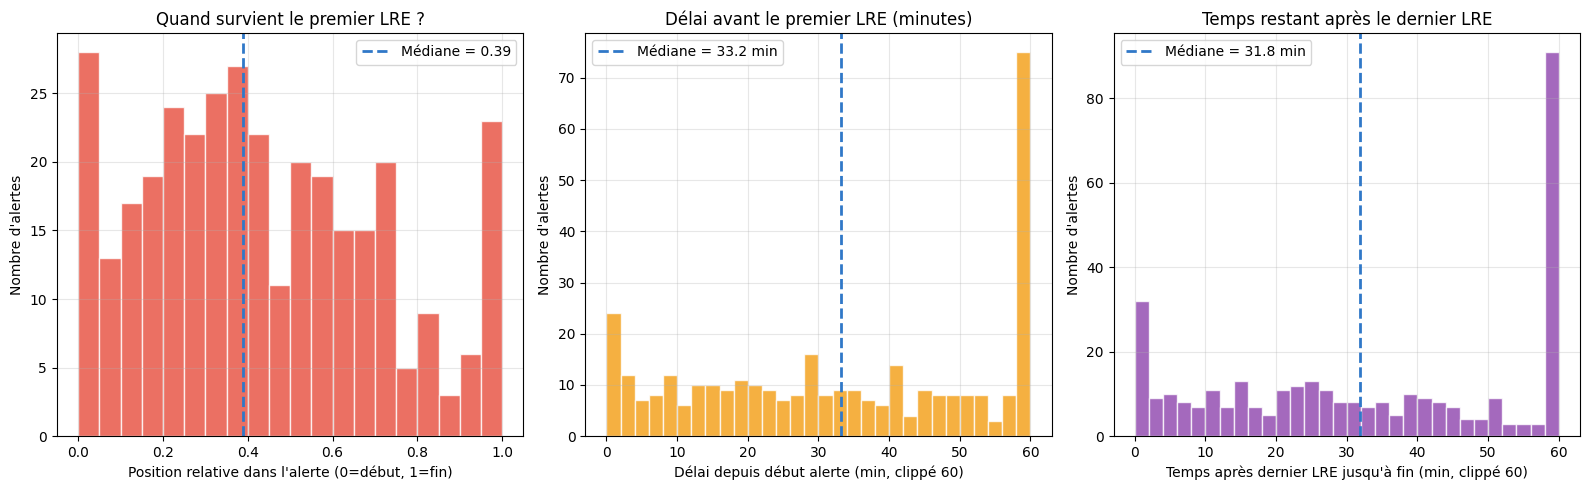

In [57]:
# %%
# Visualisation

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Distribution position relative du premier LRE
axes[0].hist(timing_df["pos_premier_lre"], bins=20,
             color="#e74c3c", alpha=0.8, edgecolor="white")
axes[0].axvline(timing_df["pos_premier_lre"].median(),
                color="#3078c8", linestyle="--", linewidth=2,
                label=f"Médiane = {timing_df['pos_premier_lre'].median():.2f}")
axes[0].set_xlabel("Position relative dans l'alerte (0=début, 1=fin)")
axes[0].set_ylabel("Nombre d'alertes")
axes[0].set_title("Quand survient le premier LRE ?")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Délai en minutes avant le premier LRE
axes[1].hist(timing_df["delai_premier_lre_min"].clip(upper=60),
             bins=30, color="#f39c12", alpha=0.8, edgecolor="white")
axes[1].axvline(timing_df["delai_premier_lre_min"].median(),
                color="#3078c8", linestyle="--", linewidth=2,
                label=f"Médiane = {timing_df['delai_premier_lre_min'].median():.1f} min")
axes[1].set_xlabel("Délai depuis début alerte (min, clippé 60)")
axes[1].set_ylabel("Nombre d'alertes")
axes[1].set_title("Délai avant le premier LRE (minutes)")
axes[1].legend()
axes[1].grid(alpha=0.3)

# Temps restant après le dernier LRE
axes[2].hist(timing_df["temps_apres_dernier_lre_min"].clip(upper=60),
             bins=30, color="#8e44ad", alpha=0.8, edgecolor="white")
axes[2].axvline(timing_df["temps_apres_dernier_lre_min"].median(),
                color="#3078c8", linestyle="--", linewidth=2,
                label=f"Médiane = {timing_df['temps_apres_dernier_lre_min'].median():.1f} min")
axes[2].set_xlabel("Temps après dernier LRE jusqu'à fin (min, clippé 60)")
axes[2].set_ylabel("Nombre d'alertes")
axes[2].set_title("Temps restant après le dernier LRE")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    "/home/onyxia/work/Dataverse/Dataverse/output/lre_timing.png",
    dpi=130, bbox_inches="tight"
)
plt.show()

In [58]:
# %%
# Pour les LRE qui surviennent dans la 2ème moitié de l'alerte,
# combien sont précédés d'un autre LRE ?
# = est-ce qu'un LRE tardif est souvent un rebond isolé ou fait partie d'une série ?

import pandas as pd
import numpy as np

RAW_PATH = "/home/onyxia/work/Dataverse/Dataverse/data/segment_alerts_all_airports_train.csv"
df_raw = pd.read_csv(RAW_PATH)
df_raw["date"] = pd.to_datetime(df_raw["date"], utc=True)
df_raw["type"] = np.where(df_raw["icloud"].fillna(False), "IC", "CG")

LRE_DIST = 3.0

rows = []

for (airport, alert_id), group in df_raw[
    df_raw["airport_alert_id"].notna()
].groupby(["airport", "airport_alert_id"]):

    group = group.sort_values("date").reset_index(drop=True)
    lre = group[group["dist"] < LRE_DIST].reset_index(drop=True)

    if len(lre) == 0:
        continue

    t_debut = group["date"].iloc[0]
    t_fin = group["date"].iloc[-1]
    duree = (t_fin - t_debut).total_seconds() / 60.0

    if duree == 0:
        continue

    # Pour chaque LRE de l'alerte
    for i, lre_row in lre.iterrows():
        t_lre = lre_row["date"]
        pos = (t_lre - t_debut).total_seconds() / 60.0 / duree

        # Est-il dans la 2ème moitié ?
        in_second_half = pos >= 0.5

        # Y a-t-il un LRE précédent dans l'alerte ?
        has_previous_lre = i > 0

        # Si oui, quel est le délai depuis le LRE précédent ?
        if has_previous_lre:
            t_prev_lre = lre.iloc[i - 1]["date"]
            gap_since_prev_lre = (t_lre - t_prev_lre).total_seconds() / 60.0
        else:
            gap_since_prev_lre = np.nan

        rows.append({
            "airport": airport,
            "alert_id": alert_id,
            "pos_relative": round(pos, 3),
            "in_second_half": in_second_half,
            "has_previous_lre": has_previous_lre,
            "gap_since_prev_lre_min": gap_since_prev_lre,
            "lre_type": lre_row["type"],
            "lre_dist": lre_row["dist"],
        })

lre_df = pd.DataFrame(rows)

print(f"Total LRE analysés : {len(lre_df)}")
print(f"LRE en 2ème moitié : {lre_df['in_second_half'].sum()} "
      f"({100*lre_df['in_second_half'].mean():.1f}%)")

Total LRE analysés : 1237
LRE en 2ème moitié : 567 (45.8%)


In [59]:
# %%
# Résultats : LRE tardifs précédés ou non d'un autre LRE

lre_2nd = lre_df[lre_df["in_second_half"]].copy()

print("=== LRE dans la 2ème moitié de l'alerte ===\n")
print(f"Total                          : {len(lre_2nd)}")
print(f"Précédés d'un autre LRE        : {lre_2nd['has_previous_lre'].sum()} "
      f"({100*lre_2nd['has_previous_lre'].mean():.1f}%)")
print(f"Sans LRE précédent (rebond pur): {(~lre_2nd['has_previous_lre']).sum()} "
      f"({100*(~lre_2nd['has_previous_lre']).mean():.1f}%)")

print("\n=== Délai depuis le LRE précédent (pour ceux qui en ont un) ===\n")
print(lre_2nd[lre_2nd["has_previous_lre"]]["gap_since_prev_lre_min"].describe().round(2))

print("\n=== Délai par catégorie ===")
gaps = lre_2nd[lre_2nd["has_previous_lre"]]["gap_since_prev_lre_min"]
print(f"  < 5 min  (série continue)   : {(gaps < 5).sum()} ({100*(gaps<5).mean():.1f}%)")
print(f"  5-15 min (court délai)       : {((gaps>=5)&(gaps<15)).sum()} "
      f"({100*((gaps>=5)&(gaps<15)).mean():.1f}%)")
print(f"  15-30 min (délai moyen)      : {((gaps>=15)&(gaps<30)).sum()} "
      f"({100*((gaps>=15)&(gaps<30)).mean():.1f}%)")
print(f"  > 30 min (vrai rebond tardif): {(gaps>=30).sum()} "
      f"({100*(gaps>=30).mean():.1f}%)")

=== LRE dans la 2ème moitié de l'alerte ===

Total                          : 567
Précédés d'un autre LRE        : 432 (76.2%)
Sans LRE précédent (rebond pur): 135 (23.8%)

=== Délai depuis le LRE précédent (pour ceux qui en ont un) ===

count    432.00
mean       8.42
std       17.84
min        0.00
25%        0.82
50%        2.39
75%        7.70
max      202.02
Name: gap_since_prev_lre_min, dtype: float64

=== Délai par catégorie ===
  < 5 min  (série continue)   : 290 (67.1%)
  5-15 min (court délai)       : 77 (17.8%)
  15-30 min (délai moyen)      : 35 (8.1%)
  > 30 min (vrai rebond tardif): 30 (6.9%)


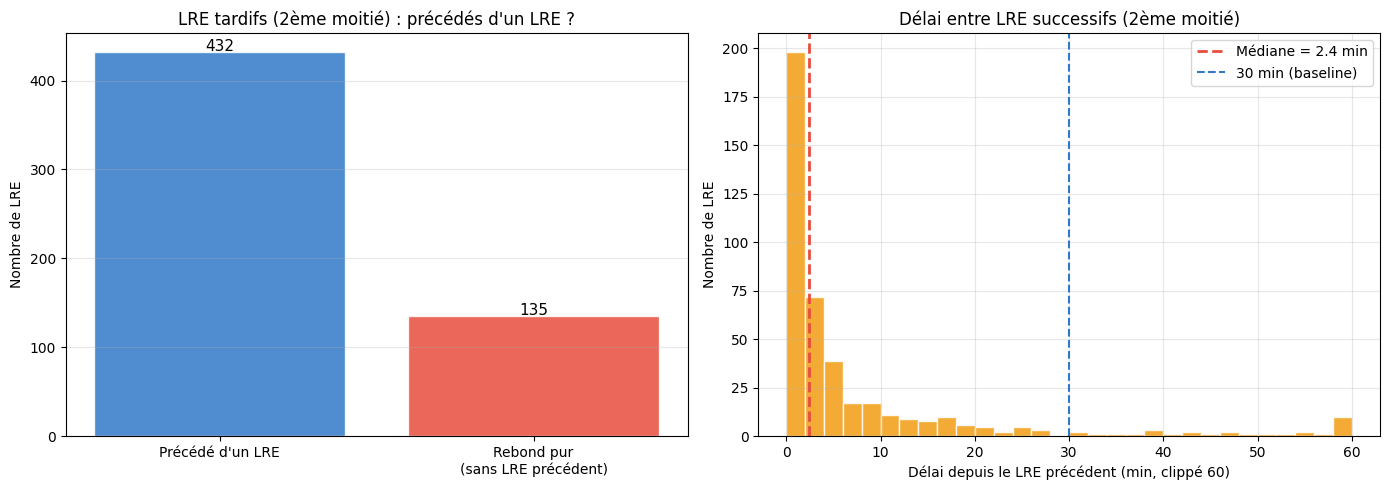

In [60]:
# %%
# Visualisation

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Proportion précédé/non précédé
labels = ["Précédé d'un LRE", "Rebond pur\n(sans LRE précédent)"]
vals = [
    lre_2nd["has_previous_lre"].sum(),
    (~lre_2nd["has_previous_lre"]).sum()
]
axes[0].bar(labels, vals, color=["#3078c8", "#e74c3c"], alpha=0.85,
            edgecolor="white")
for i, v in enumerate(vals):
    axes[0].text(i, v + 1, str(v), ha="center", fontsize=11, fontweight="500")
axes[0].set_title("LRE tardifs (2ème moitié) : précédés d'un LRE ?")
axes[0].set_ylabel("Nombre de LRE")
axes[0].grid(alpha=0.3, axis="y")

# Distribution du délai depuis le LRE précédent
gaps = lre_2nd[lre_2nd["has_previous_lre"]]["gap_since_prev_lre_min"].clip(upper=60)
axes[1].hist(gaps, bins=30, color="#f39c12", alpha=0.85, edgecolor="white")
axes[1].axvline(gaps.median(), color="#e74c3c", linestyle="--", linewidth=2,
                label=f"Médiane = {gaps.median():.1f} min")
axes[1].axvline(30, color="#3078c8", linestyle="--", linewidth=1.5,
                label="30 min (baseline)")
axes[1].set_xlabel("Délai depuis le LRE précédent (min, clippé 60)")
axes[1].set_ylabel("Nombre de LRE")
axes[1].set_title("Délai entre LRE successifs (2ème moitié)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    "/home/onyxia/work/Dataverse/Dataverse/output/lre_rebonds_tardifs.png",
    dpi=130, bbox_inches="tight"
)
plt.show()

In [64]:
# %%
# Tout en un — caractérisation rebonds purs

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RAW_PATH = "/home/onyxia/work/Dataverse/Dataverse/data/segment_alerts_all_airports_train.csv"
LRE_DIST = 3.0

df_raw = pd.read_csv(RAW_PATH)
df_raw["date"] = pd.to_datetime(df_raw["date"], utc=True)
df_raw["type"] = np.where(df_raw["icloud"].fillna(False), "IC", "CG")
df_raw["zone"] = np.where(df_raw["dist"] < 20, "inner", "outer")

# Étape 1 : identifier les alertes avec rebond pur
rebond_pur_alerts = set()
for (airport, alert_id), group in df_raw[
    df_raw["airport_alert_id"].notna()
].groupby(["airport", "airport_alert_id"]):
    group = group.sort_values("date").reset_index(drop=True)
    lre = group[group["dist"] < LRE_DIST].reset_index(drop=True)
    if len(lre) == 0:
        continue
    t_debut = group["date"].iloc[0]
    t_fin = group["date"].iloc[-1]
    duree = (t_fin - t_debut).total_seconds() / 60.0
    if duree == 0:
        continue
    for i, lre_row in lre.iterrows():
        t_lre = lre_row["date"]
        pos = (t_lre - t_debut).total_seconds() / 60.0 / duree
        if pos >= 0.5 and i == 0:
            rebond_pur_alerts.add((airport, alert_id))
            break

print(f"Alertes avec rebond pur : {len(rebond_pur_alerts)}")

# Étape 2 : construire stats_df
alert_stats = []
for (airport, alert_id), group in df_raw[
    df_raw["airport_alert_id"].notna()
].groupby(["airport", "airport_alert_id"]):
    group = group.sort_values("date").reset_index(drop=True)
    cg_inner = group[(group["type"] == "CG") & (group["zone"] == "inner")]
    lre = group[group["dist"] < LRE_DIST]
    t_debut = group["date"].iloc[0]
    t_fin = group["date"].iloc[-1]
    duree = (t_fin - t_debut).total_seconds() / 60.0

    if (airport, alert_id) in rebond_pur_alerts:
        categorie = "rebond pur"
    elif len(lre) > 0:
        categorie = "LRE normal"
    else:
        categorie = "sans LRE"

    alert_stats.append({
        "airport": airport,
        "alert_id": alert_id,
        "categorie": categorie,
        "duree_min": duree,
        "n_cg_inner": len(cg_inner),
        "n_lre": len(lre),
        "dist_min": group["dist"].min(),
        "n_total": len(group),
        "mois": group["date"].iloc[0].month,
        "heure": group["date"].iloc[0].hour,
    })

stats_df = pd.DataFrame(alert_stats)

# Étape 3 : afficher les résultats
print("\n=== Profil des alertes selon catégorie ===\n")
print(stats_df.groupby("categorie")[
    ["duree_min", "n_cg_inner", "dist_min", "n_total"]
].agg(["mean", "median"]).round(2).to_string())

print("\n=== Mois des alertes avec rebond pur ===\n")
mois_labels = {1:"Jan",2:"Fév",3:"Mar",4:"Avr",5:"Mai",6:"Jun",
               7:"Jul",8:"Aoû",9:"Sep",10:"Oct",11:"Nov",12:"Déc"}
for cat in ["rebond pur", "LRE normal", "sans LRE"]:
    sub = stats_df[stats_df["categorie"] == cat]
    mois_dist = sub["mois"].value_counts().sort_index()
    top3 = mois_dist.nlargest(3).index.map(mois_labels).tolist()
    print(f"{cat:15} → top 3 mois : {top3}")

print("\n=== Heure de début ===\n")
for cat in ["rebond pur", "LRE normal", "sans LRE"]:
    sub = stats_df[stats_df["categorie"] == cat]
    heure_med = sub["heure"].median()
    print(f"{cat:15} → heure médiane : {heure_med:.0f}h UTC")

Alertes avec rebond pur : 135

=== Profil des alertes selon catégorie ===

           duree_min        n_cg_inner        dist_min        n_total       
                mean median       mean median     mean median    mean median
categorie                                                                   
LRE normal    105.04  85.33     140.27   60.0     1.55   1.46  140.27   60.0
rebond pur     88.24  73.80      65.96   37.0     1.72   1.69   65.96   37.0
sans LRE       19.01   4.57       7.18    2.0    12.35  12.90    7.18    2.0

=== Mois des alertes avec rebond pur ===

rebond pur      → top 3 mois : ['Aoû', 'Jun', 'Mai']
LRE normal      → top 3 mois : ['Aoû', 'Sep', 'Jul']
sans LRE        → top 3 mois : ['Sep', 'Nov', 'Aoû']

=== Heure de début ===

rebond pur      → heure médiane : 12h UTC
LRE normal      → heure médiane : 11h UTC
sans LRE        → heure médiane : 12h UTC


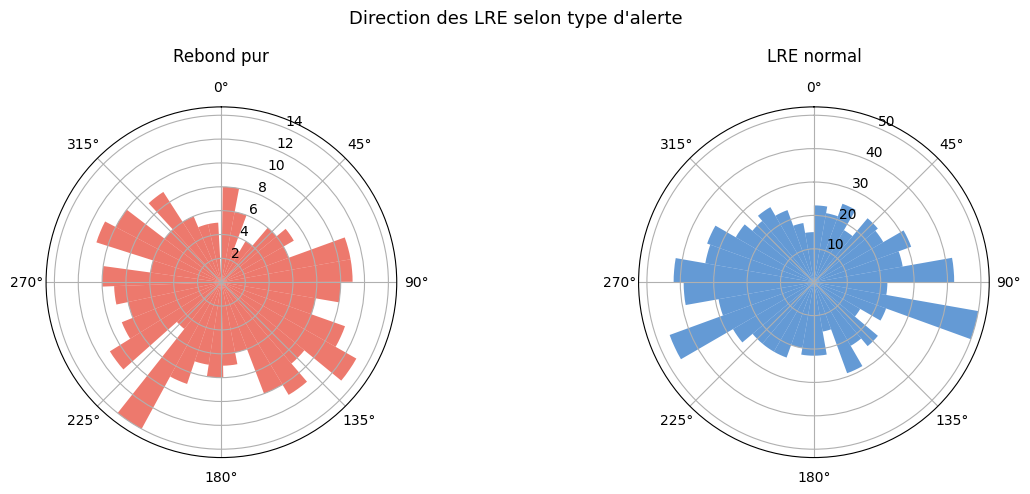

In [65]:
# %%
# Direction (azimuth) des rebonds purs
# Est-ce que les LRE très proches viennent d'un secteur particulier ?

import numpy as np
import matplotlib.pyplot as plt

rebond_azimuths = []
normal_azimuths = []

for (airport, alert_id), group in df_raw[
    df_raw["airport_alert_id"].notna()
].groupby(["airport", "airport_alert_id"]):
    lre = group[group["dist"] < LRE_DIST]
    if len(lre) == 0:
        continue
    if (airport, alert_id) in rebond_pur_alerts:
        rebond_azimuths.extend(lre["azimuth"].dropna().tolist())
    else:
        normal_azimuths.extend(lre["azimuth"].dropna().tolist())

fig, axes = plt.subplots(1, 2, figsize=(12, 5),
                         subplot_kw=dict(projection="polar"))

for ax, azimuths, label, color in [
    (axes[0], rebond_azimuths, "Rebond pur", "#e74c3c"),
    (axes[1], normal_azimuths, "LRE normal", "#3078c8"),
]:
    rad = np.radians(azimuths)
    ax.hist(rad, bins=36, color=color, alpha=0.75)
    ax.set_title(label, pad=14)
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

plt.suptitle("Direction des LRE selon type d'alerte", fontsize=13)
plt.tight_layout()
plt.show()

In [66]:
# %%
# Est-ce que les rebonds purs sont précédés d'éclairs qui s'approchent ?
# On regarde la tendance de dist dans les 10 et 20 minutes avant le rebond pur

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

RAW_PATH = "/home/onyxia/work/Dataverse/Dataverse/data/segment_alerts_all_airports_train.csv"
LRE_DIST = 3.0

df_raw = pd.read_csv(RAW_PATH)
df_raw["date"] = pd.to_datetime(df_raw["date"], utc=True)
df_raw["type"] = np.where(df_raw["icloud"].fillna(False), "IC", "CG")
df_raw["zone"] = np.where(df_raw["dist"] < 20, "inner", "outer")

# Reconstruire rebond_pur_alerts si pas en mémoire
rebond_pur_alerts = set()
for (airport, alert_id), group in df_raw[
    df_raw["airport_alert_id"].notna()
].groupby(["airport", "airport_alert_id"]):
    group = group.sort_values("date").reset_index(drop=True)
    lre = group[group["dist"] < LRE_DIST].reset_index(drop=True)
    if len(lre) == 0:
        continue
    t_debut = group["date"].iloc[0]
    t_fin = group["date"].iloc[-1]
    duree = (t_fin - t_debut).total_seconds() / 60.0
    if duree == 0:
        continue
    for i, lre_row in lre.iterrows():
        t_lre = lre_row["date"]
        pos = (t_lre - t_debut).total_seconds() / 60.0 / duree
        if pos >= 0.5 and i == 0:
            rebond_pur_alerts.add((airport, alert_id))
            break

print(f"Rebond pur alerts : {len(rebond_pur_alerts)}")

Rebond pur alerts : 135


In [68]:
# %%
# Pour chaque rebond pur, calculer la tendance de dist
# dans les 10 et 20 minutes qui précèdent

from scipy import stats

approach_rows = []

for (airport, alert_id), group in df_raw[
    df_raw["airport_alert_id"].notna()
].groupby(["airport", "airport_alert_id"]):

    if (airport, alert_id) not in rebond_pur_alerts:
        continue

    group = group.sort_values("date").reset_index(drop=True)
    lre = group[group["dist"] < LRE_DIST].reset_index(drop=True)

    t_debut = group["date"].iloc[0]
    t_fin = group["date"].iloc[-1]
    duree = (t_fin - t_debut).total_seconds() / 60.0

    for i, lre_row in lre.iterrows():
        t_lre = lre_row["date"]
        pos = (t_lre - t_debut).total_seconds() / 60.0 / duree
        if pos >= 0.5 and i == 0:

            for window_min in [5, 10, 20]:
                w_start = t_lre - pd.Timedelta(minutes=window_min)
                before = group[
                    (group["date"] >= w_start) &
                    (group["date"] < t_lre)
                ].copy()

                if len(before) < 3:
                    approach_rows.append({
                        "airport": airport,
                        "alert_id": alert_id,
                        "window_min": window_min,
                        "n_events": len(before),
                        "slope_dist": np.nan,
                        "dist_min_before": np.nan,
                        "dist_mean_before": np.nan,
                        "pct_ic": np.nan,
                    })
                    continue

                t_seconds = (
                    before["date"] - before["date"].iloc[0]
                ).dt.total_seconds()

                # Cas où tous les timestamps sont identiques
                if t_seconds.nunique() < 2:
                    approach_rows.append({
                        "airport": airport,
                        "alert_id": alert_id,
                        "window_min": window_min,
                        "n_events": len(before),
                        "slope_dist": np.nan,
                        "dist_min_before": before["dist"].min(),
                        "dist_mean_before": before["dist"].mean(),
                        "pct_ic": (before["type"] == "IC").mean(),
                    })
                    continue

                slope, intercept, r, p, se = stats.linregress(
                    t_seconds, before["dist"]
                )

                approach_rows.append({
                    "airport": airport,
                    "alert_id": alert_id,
                    "window_min": window_min,
                    "n_events": len(before),
                    "slope_dist": slope,
                    "dist_min_before": before["dist"].min(),
                    "dist_mean_before": before["dist"].mean(),
                    "pct_ic": (before["type"] == "IC").mean(),
                })
            break

approach_df = pd.DataFrame(approach_rows)
print(f"Rebonds analysés : {approach_df['alert_id'].nunique()}")

Rebonds analysés : 124


In [69]:
# %%
# Résultats : tendance de dist avant le rebond

print("=== Tendance de la distance avant le rebond pur ===\n")

for w in [5, 10, 20]:
    sub = approach_df[
        (approach_df["window_min"] == w) &
        approach_df["slope_dist"].notna()
    ]
    if len(sub) == 0:
        print(f"Fenêtre {w:2d} min : pas assez de données\n")
        continue

    n_approach = (sub["slope_dist"] < 0).sum()
    n_recul    = (sub["slope_dist"] > 0).sum()
    print(f"Fenêtre {w:2d} min ({len(sub)} rebonds) :")
    print(f"  Éclairs qui s'approchent (slope < 0) : "
          f"{n_approach} ({100*n_approach/len(sub):.1f}%)")
    print(f"  Éclairs qui s'éloignent  (slope > 0) : "
          f"{n_recul} ({100*n_recul/len(sub):.1f}%)")
    print(f"  Slope médiane            : {sub['slope_dist'].median():.5f} km/s")
    print(f"  dist_min médiane avant   : {sub['dist_min_before'].median():.2f} km")
    print(f"  % IC avant rebond        : {sub['pct_ic'].median()*100:.1f}%")
    print()

=== Tendance de la distance avant le rebond pur ===

Fenêtre  5 min (62 rebonds) :
  Éclairs qui s'approchent (slope < 0) : 28 (45.2%)
  Éclairs qui s'éloignent  (slope > 0) : 34 (54.8%)
  Slope médiane            : 0.00103 km/s
  dist_min médiane avant   : 6.05 km
  % IC avant rebond        : 0.0%

Fenêtre 10 min (88 rebonds) :
  Éclairs qui s'approchent (slope < 0) : 53 (60.2%)
  Éclairs qui s'éloignent  (slope > 0) : 35 (39.8%)
  Slope médiane            : -0.00193 km/s
  dist_min médiane avant   : 5.52 km
  % IC avant rebond        : 0.0%

Fenêtre 20 min (109 rebonds) :
  Éclairs qui s'approchent (slope < 0) : 73 (67.0%)
  Éclairs qui s'éloignent  (slope > 0) : 36 (33.0%)
  Slope médiane            : -0.00269 km/s
  dist_min médiane avant   : 5.21 km
  % IC avant rebond        : 0.0%



In [70]:
# %%
# Les 33% qui s'éloignent avant le rebond — passage brusque ou lointain ?
# On regarde la dist_min et dist_mean juste avant le rebond
# pour ces cas "slope > 0" sur 20 min

sub_20 = approach_df[
    (approach_df["window_min"] == 20) &
    approach_df["slope_dist"].notna()
].copy()

sub_eloigne = sub_20[sub_20["slope_dist"] > 0]
sub_approche = sub_20[sub_20["slope_dist"] < 0]

print("=== Profil des rebonds selon la tendance (fenêtre 20 min) ===\n")
print(f"{'':30} {'S approche':>12} {'S éloigne':>12}")
print("-" * 56)

for col, label in [
    ("dist_min_before",  "dist_min avant (km)"),
    ("dist_mean_before", "dist_mean avant (km)"),
    ("n_events",         "nb éclairs avant"),
]:
    v1 = sub_approche[col].median()
    v2 = sub_eloigne[col].median()
    print(f"{label:30} {v1:>12.2f} {v2:>12.2f}")

print()
print("=== dist_min avant le rebond — s'éloigne ===\n")
print(sub_eloigne["dist_min_before"].describe().round(2))

print("\n=== Interprétation ===")
pct_loin = (sub_eloigne["dist_min_before"] > 10).sum()
pct_proche = (sub_eloigne["dist_min_before"] <= 10).sum()
print(f"dist_min > 10 km (loin)    : {pct_loin} ({100*pct_loin/len(sub_eloigne):.1f}%)")
print(f"dist_min <= 10 km (proche) : {pct_proche} ({100*pct_proche/len(sub_eloigne):.1f}%)")
print(f"\n→ Si dist_min > 10 km ET slope > 0 : rebond vraiment brusque depuis loin")
print(f"→ Si dist_min <= 10 km ET slope > 0 : oscillation locale autour de 5-10 km")

=== Profil des rebonds selon la tendance (fenêtre 20 min) ===

                                 S approche    S éloigne
--------------------------------------------------------
dist_min avant (km)                    4.91         6.16
dist_mean avant (km)                  11.50        13.26
nb éclairs avant                      11.00        11.00

=== dist_min avant le rebond — s'éloigne ===

count    36.00
mean      7.08
std       3.35
min       3.00
25%       4.59
50%       6.16
75%       9.43
max      15.59
Name: dist_min_before, dtype: float64

=== Interprétation ===
dist_min > 10 km (loin)    : 5 (13.9%)
dist_min <= 10 km (proche) : 31 (86.1%)

→ Si dist_min > 10 km ET slope > 0 : rebond vraiment brusque depuis loin
→ Si dist_min <= 10 km ET slope > 0 : oscillation locale autour de 5-10 km


In [71]:
# %%
# Intensité des orages avec rebonds purs
# On regarde l'amplitude des éclairs avant le rebond
# et compare avec les autres catégories

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=== Intensité des orages selon catégorie ===\n")

intensity_rows = []

for (airport, alert_id), group in df_raw[
    df_raw["airport_alert_id"].notna()
].groupby(["airport", "airport_alert_id"]):

    group = group.sort_values("date").reset_index(drop=True)
    lre = group[group["dist"] < LRE_DIST]
    cg_inner = group[
        (group["type"] == "CG") & (group["zone"] == "inner")
    ]

    if (airport, alert_id) in rebond_pur_alerts:
        categorie = "rebond pur"
    elif len(lre) > 0:
        categorie = "LRE normal"
    else:
        categorie = "sans LRE"

    intensity_rows.append({
        "airport": airport,
        "alert_id": alert_id,
        "categorie": categorie,
        # Amplitude absolue moyenne de tous les éclairs
        "amp_abs_mean": group["amplitude"].abs().mean(),
        # Amplitude absolue max
        "amp_abs_max": group["amplitude"].abs().max(),
        # Amplitude des CG inner uniquement
        "amp_cg_inner_mean": cg_inner["amplitude"].abs().mean()
            if len(cg_inner) > 0 else np.nan,
        # maxis moyen (indicateur d'intensité Meteorage)
        "maxis_mean": group["maxis"].mean(),
        "maxis_max": group["maxis"].max(),
        # Nombre de CG inner
        "n_cg_inner": len(cg_inner),
        # Durée
        "duree_min": (group["date"].iloc[-1] - group["date"].iloc[0]
                      ).total_seconds() / 60.0,
    })

intensity_df = pd.DataFrame(intensity_rows)

print(intensity_df.groupby("categorie")[
    ["amp_abs_mean", "amp_abs_max", "amp_cg_inner_mean",
     "maxis_mean", "maxis_max", "n_cg_inner"]
].agg(["mean", "median"]).round(2).to_string())

=== Intensité des orages selon catégorie ===

           amp_abs_mean        amp_abs_max        amp_cg_inner_mean        maxis_mean        maxis_max        n_cg_inner       
                   mean median        mean median              mean median       mean median      mean median       mean median
categorie                                                                                                                      
LRE normal        26.42  19.14      111.30  92.01             26.42  19.14       0.60   0.43      3.28   4.11     140.27   60.0
rebond pur        26.44  19.10      104.63  86.74             26.44  19.10       0.57   0.38      3.13   3.57      65.96   37.0
sans LRE          32.27  19.92       56.03  30.76             32.27  19.92       0.64   0.19      1.28   0.36       7.18    2.0


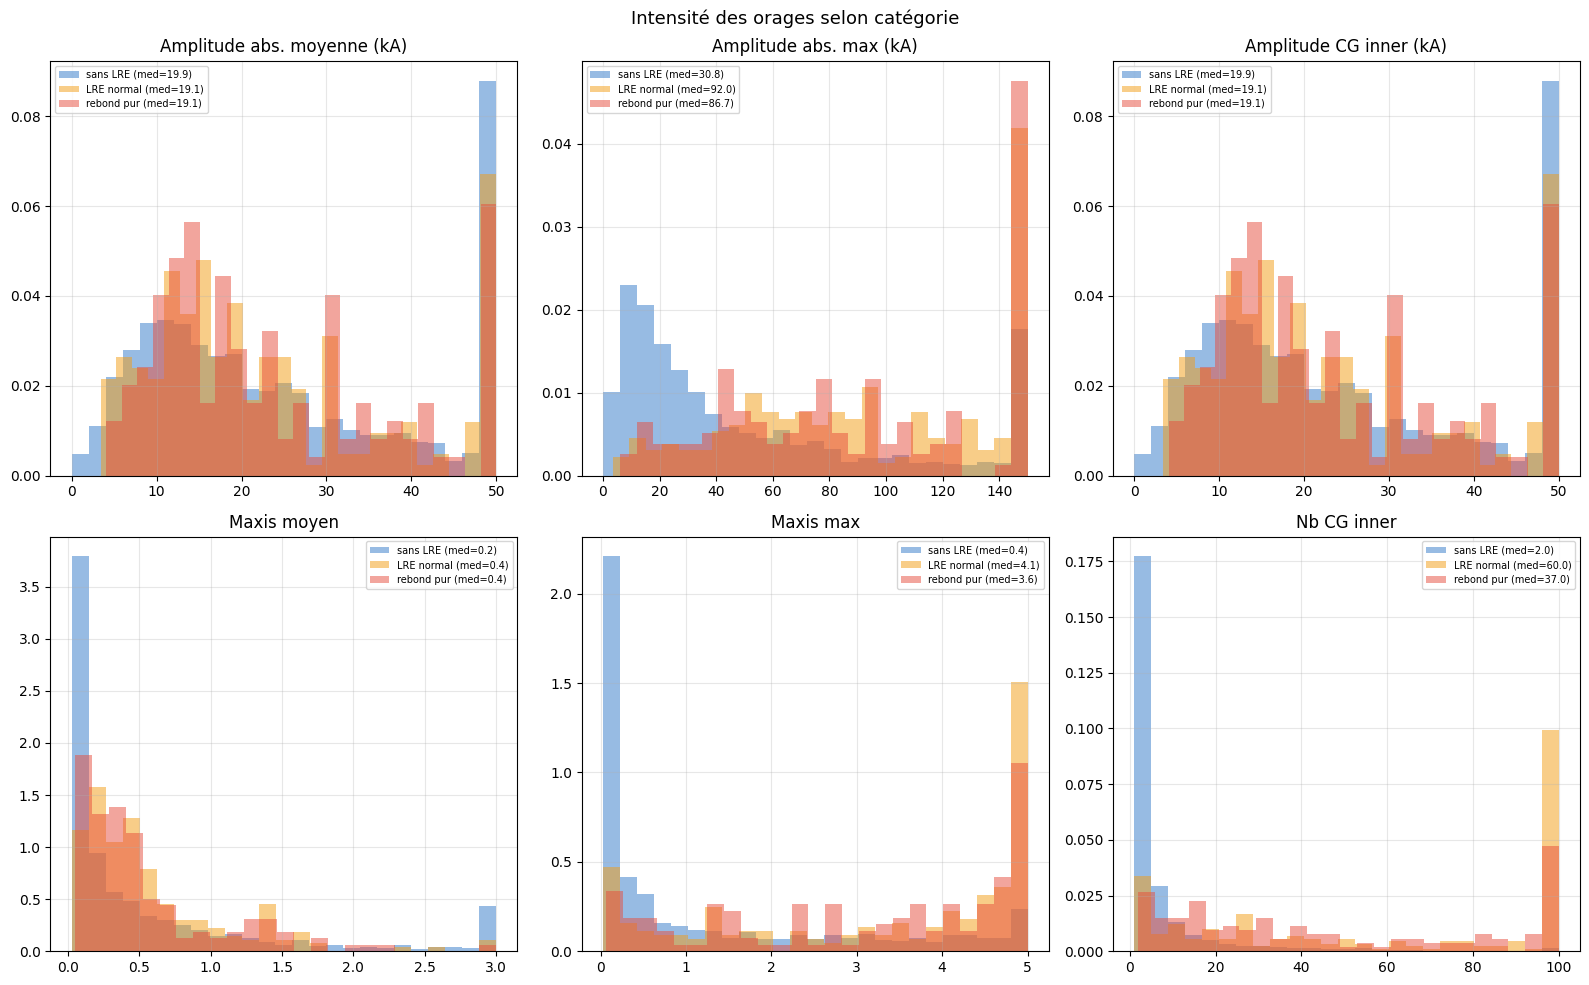

In [73]:
# %%
# Visualisation intensité

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

cats = ["sans LRE", "LRE normal", "rebond pur"]
colors = ["#3078c8", "#f39c12", "#e74c3c"]

variables = [
    ("amp_abs_mean",      "Amplitude abs. moyenne (kA)", 50),
    ("amp_abs_max",       "Amplitude abs. max (kA)",     150),
    ("amp_cg_inner_mean", "Amplitude CG inner (kA)",     50),
    ("maxis_mean",        "Maxis moyen",                 3),
    ("maxis_max",         "Maxis max",                   5),
    ("n_cg_inner",        "Nb CG inner",                 100),
]

for idx, (var, label, clip_val) in enumerate(variables):
    row, col = idx // 3, idx % 3
    for cat, color in zip(cats, colors):
        data = intensity_df[
            intensity_df["categorie"] == cat
        ][var].dropna().clip(upper=clip_val)
        axes[row][col].hist(
            data, bins=25, alpha=0.5,
            label=f"{cat} (med={data.median():.1f})",
            color=color, density=True
        )
    axes[row][col].set_title(label)
    axes[row][col].legend(fontsize=7)
    axes[row][col].grid(alpha=0.3)

plt.suptitle("Intensité des orages selon catégorie", fontsize=13)
plt.tight_layout()
plt.savefig(
    "/home/onyxia/work/Dataverse/Dataverse/output/lre_intensite.png",
    dpi=130, bbox_inches="tight"
)
plt.show()

In [72]:
# %%
# Conclusion intensité

print("=== Résumé intensité — médiane par catégorie ===\n")
print(f"{'':25} {'sans LRE':>10} {'LRE normal':>12} {'rebond pur':>12}")
print("-" * 62)

for var, label in [
    ("amp_abs_mean",      "Amplitude moy (kA)"),
    ("amp_abs_max",       "Amplitude max (kA)"),
    ("maxis_mean",        "Maxis moyen"),
    ("n_cg_inner",        "Nb CG inner"),
    ("duree_min",         "Durée (min)"),
]:
    vals = []
    for cat in ["sans LRE", "LRE normal", "rebond pur"]:
        v = intensity_df[intensity_df["categorie"]==cat][var].median()
        vals.append(v)
    print(f"{label:25} {vals[0]:>10.1f} {vals[1]:>12.1f} {vals[2]:>12.1f}")

=== Résumé intensité — médiane par catégorie ===

                            sans LRE   LRE normal   rebond pur
--------------------------------------------------------------
Amplitude moy (kA)              19.9         19.1         19.1
Amplitude max (kA)              30.8         92.0         86.7
Maxis moyen                      0.2          0.4          0.4
Nb CG inner                      2.0         60.0         37.0
Durée (min)                      4.6         85.3         73.8
